# Comparison Between using a Projection Matrix and Introduction of Slack Variables to Handle Infeasibility in QUT Methodology

Linear optimization is a powerful tool to minimize or maximum an objective function given a system of linear equations and constraints. However, in high dimensional systems the objective function can become impossible to solve given strict constraints. In our case, the strict constraint of $\lambda_{\max}=\min_{\boldsymbol{w}\in\mathbb{R}^{m}}\|\boldsymbol{w}\|_{\infty}\quad\text{subject to}\quad D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}$. The $\quad D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}$ constraint can become troublesome because it is a strict equality that can cause infeasibility even in numerically stable problems. In short,  if this constraint cannot be satisfied, the optimization algorithm will still be considered infeasible even if the estimation of $||\boldsymbol{w}\|_{\infty}$ is extremely close to the requirements. To handle this, we can a use projection matrix that utilizes the **Moore-Penrose inverse** to project the gradient $\boldsymbol{g}$ or equivalently $X^T(y-p)$ onto the column space of $D^T$, or we can introduce a small, uniform slack term per sector $\epsilon$ in the objective function that modifies it to an equality that we can represent as $\quad |D^{\mathsf T}\boldsymbol{w}-\boldsymbol{g}| \leq \epsilon$. Both methods account for any constant gradient patterns that do not vary across neighboring sectors in different ways. This notebook will describe the difference between the two methods, but first we must describe the method from the bottom up and introduce both solutions when using the **Quantile Universal Threshold (QUT)** method to estimate $\lambda$. 

## 1. Null Logistic Regression

Within the context of TV-smoothing we use the above optimization problem to solve for $\lambda_{\max}$, the optimal penalty term that drives propensity scores across sectors to zero under the null hypothesis of each sector contributes equally to threat propensity so only how many sectors you visit matters, not which sectors. To accomplish this, we run a logistic model on the movement design $X \in \mathbb{R} ^ {n \times p}$ where each independent variable $p$ is a sector on the court, $n$ is the amount of observations and $y \in {(0,1)}^{n}$ is the response vector. This will produce beta values where we select one of those betas and call it $\beta_0$. Next, we collapse the design matrix $X$ into a single predictor $X_0 = X1_p$ to get a sum of sectors visited per possession. Using $\beta_0$ and $X1_p$, we can use sigmoid to generate null probabilities for each possession followed by vector notation:

\begin{aligned}
\ p_i^{(0)} = \frac{1}{1+\exp[-(X_0)_i\hat{\beta}]}
\\
\ p^0 = \sigma(X_0\hat{\beta_0})
\end{aligned}

As an example calculation, let $X_0 = X1_p = 40$ and $\beta_0 = .001$ where 40 represents how many sectors we have visited.

\begin{aligned}
\ p^0_1 = \sigma(40 \cdot .001) \approx 0.51
\end{aligned}

This operation is completed for every possession. Because of the nature of sigmoid, the calculated probabilites are likely going to be similar values. If we were to change $X_0 = X1_p = 120$ and keep $\beta_0 = .001$, we would get the following probability:

\begin{aligned}
\ p^0_2 = \sigma(120 \cdot .001) \approx 0.52
\end{aligned}

When comparing $p^0_1$ to $p^0_2$, tripling the amount of sectors visited only results in $1\%$ increase in probability of scoring. This property will become important in the next few sections where we calculate the **null likelihood gradient**.

## 2. Null Log-Likelihood Gradient

The null likelihood gradient represents the contribution each sector has under the null hypothesis. With the above calculations with toy examples, each sector in each possession represented in $X$ will have a similar value, creating a constant signal across all sectors. The calculation is shown below.

\begin{aligned}
\ g = grad_h = X^{T}(y - p^0),
\ g\in\mathbb{R}^{p}
\end{aligned}

For clarity, below is a toy example with three observations with four sectors, $y^T = (1, 0, 1)$ and $p^0 = (.52, .51, .53)$.

\begin{aligned}
X = \begin{bmatrix}
1 & 0 & 1 & 1\\
0 & 1 & 0 & 1\\
1 & 1 & 1 & 1
\end{bmatrix}
\end{aligned}

\begin{aligned}
X^T = \begin{bmatrix}
1 & 0 & 1\\
0 & 1 & 1\\
1 & 0 & 1\\
1 & 1 & 1\\
\end{bmatrix}
\end{aligned}

\begin{aligned}
X^T = \begin{bmatrix}
1 & 0 & 1\\
0 & 1 & 1\\
1 & 0 & 1\\
1 & 1 & 1\\
\end{bmatrix}
\begin{bmatrix}
.48\\
-.51\\
.47\\
\end{bmatrix}
\ = \begin{bmatrix}
.95\\ %total contribution of first sector
-.04\\ %total contribution of second sector
.95\\ %total contribution of third sector
.44\\ %total contribution of fourth sector
\end{bmatrix}
\end{aligned}

The **log-likelihood** gradient calculation represents the the total residual response under the null model for each sector to the corresponding sector coefficient. In simpler terms, it is the total score contribution that the jth sector contributed to each possession when visited.

## 3. Total Variation Matrix and Optimization Variable

QUT bin orientation method: possession_start_end_inferred
Possessions flipped for left-to-right orientation: 46 / 93
Post-orientation mean end-start x_bin: 12.5914
Generating Bootstrapped Datasets...


Generating Bootstrapped Datasets: 100%|██████████| 500/500 [02:33<00:00,  3.25it/s]

Loaded 80,704 source rows from Data\analysis_ready_half_court_filtered.csv
Source possessions: 93
Bootstrap datasets: 500
QUT bootstrap rows: 100,000
QUT bootstrap possessions: 1,000
X shape: (1000, 200); D_TV shape: (370, 200); scored rate: 0.4810
grad_h projection is OFF for this QUT run.
null beta0: -0.00593692640434
null penalty: None
null optimizer iterations: 4
null likelihood score: -5.13973e-07
sum(grad_h): -5.13973e-07
non-representable constant offset: -2.56986e-09
Distance from grad_h to col(D_TV.T): L2=3.63433e-08, Linf=2.57e-09
rank(D_TV.T)=199 / 200 variables


,variable_index,variable,grad_h,nearest_feasible_grad_h,residual,abs_residual
0,12,"x_bin=1, y_bin=2",2.566715,2.566715,-2.570001e-09,2.570001e-09
1,103,"x_bin=10, y_bin=3",-1.743310,-1.743310,-2.569997e-09,2.569997e-09
2,26,"x_bin=2, y_bin=6",1.087193,1.087193,-2.569970e-09,2.569970e-09
3,113,"x_bin=11, y_bin=3",5.373852,5.373852,-2.569969e-09,2.569969e-09
4,44,"x_bin=4, y_bin=4",-6.225935,-6.225935,-2.569962e-09,2.569962e-09
5,121,"x_bin=12, y_bin=1",23.059597,23.059597,-2.569962e-09,2.569962e-09
6,87,"x_bin=8, y_bin=7",-15.441588,-15.441588,-2.569957e-09,2.569957e-09
7,166,"x_bin=16, y_bin=6",11.830990,11.830990,-2.569953e-09,2.569953e-09
8,64,"x_bin=6, y_bin=4",-28.706608,-28.706608,-2.569951e-09,2.569951e-09
9,136,"x_bin=13, y_bin=6",-8.858523,-8.858523,-2.569951e-09,2.569951e-09


,variable_index,x_bin,y_bin,residual,abs_residual
0,12,1,2,-2.570001e-09,2.570001e-09
1,103,10,3,-2.569997e-09,2.569997e-09
2,26,2,6,-2.569970e-09,2.569970e-09
3,113,11,3,-2.569969e-09,2.569969e-09
4,44,4,4,-2.569962e-09,2.569962e-09
5,121,12,1,-2.569962e-09,2.569962e-09
6,87,8,7,-2.569957e-09,2.569957e-09
7,166,16,6,-2.569953e-09,2.569953e-09
8,64,6,4,-2.569951e-09,2.569951e-09
9,136,13,6,-2.569951e-09,2.569951e-09


...

Computing lambda_max for bootstraps: 100%|██████████| 499/499 [00:55<00:00,  8.96it/s]


,bootstrap_index,lambda_max,slack_linf,solver,error
0,1,35.022411,3.269349e-08,CLARABEL,None
1,2,32.430833,6.390819e-09,CLARABEL,None
2,3,33.946777,1.174764e-08,CLARABEL,None
3,4,28.975216,2.105450e-08,CLARABEL,None
4,5,35.869994,5.740037e-09,CLARABEL,None


lambda_qut (95th percentile null): 14.0599
lambda_max (observed): 30.4345
95% CI for lambda_max (bootstrap): [27.2521, 40.6936]
Empirical p-value (lambda_max > lambda_qut): 0.0000
Computing pointwise conservative/realistic/optimistic maps at lambda = 14.0599


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:29<00:00,  5.60it/s]


{'lambda_qut': 14.059886753674217,
 'lambda_max_obs': 30.434473172417153,
 'lambda_null': array([11.59757521,  7.73419166,  6.18861896, 14.05680793, 13.56487425,
        12.14701673,  6.45812809, 14.16398977, 14.16004511,  8.64810049,
        12.896846  ,  8.97933003,  8.88604033, 11.69052305,  6.3548575 ,
        13.65164952,  8.71760071, 14.27839111, 12.59260901, 10.32743352,
        15.21279345, 10.15728336,  8.50488185, 10.46796038,  8.75528805,
        10.22485187,  8.55859244,  8.25101005,  6.73204328,  9.88481244,
         5.78453118, 15.11890707,  7.05733783,  8.04411493,  5.81840757,
         7.91517474,  7.49841842, 10.73678627,  9.60266105, 10.65533479,
         9.33317791, 10.97788542,  9.13346501,  8.17534763,  6.27460873,
        12.66060642,  5.86964406,  8.90357487,  8.83462508, 12.27055333,
         7.57380317,  7.3001373 , 11.01970993,  7.89431603, 16.45598653,
        12.23974145,  8.00383853,  7.63506536,  9.67348205,  4.98234981,
        12.23106972, 11.66118331,  

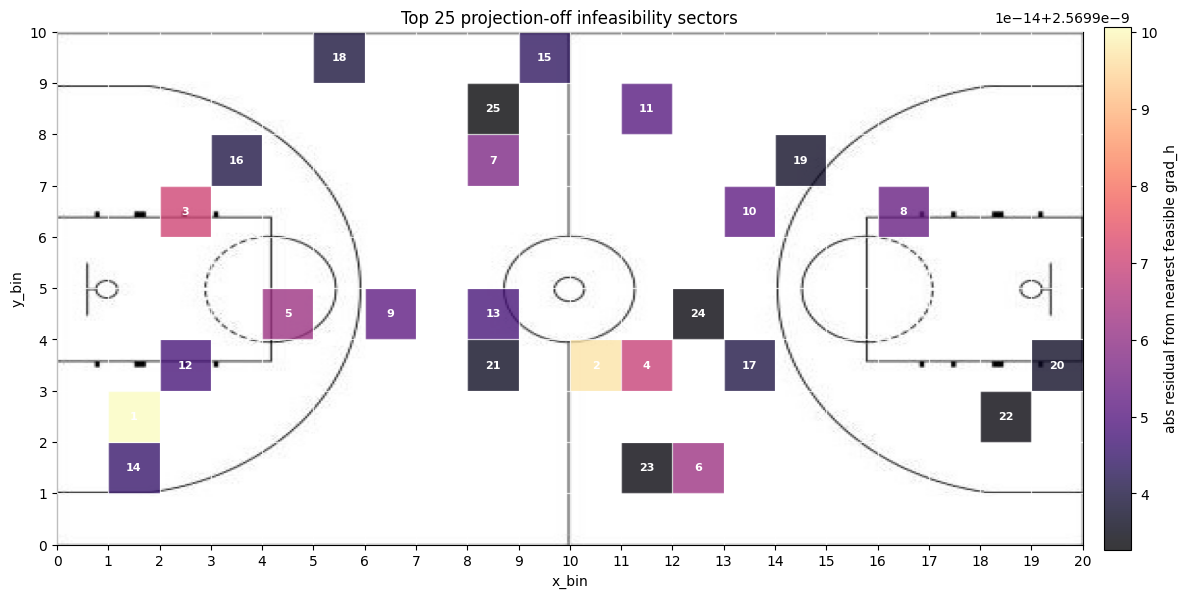

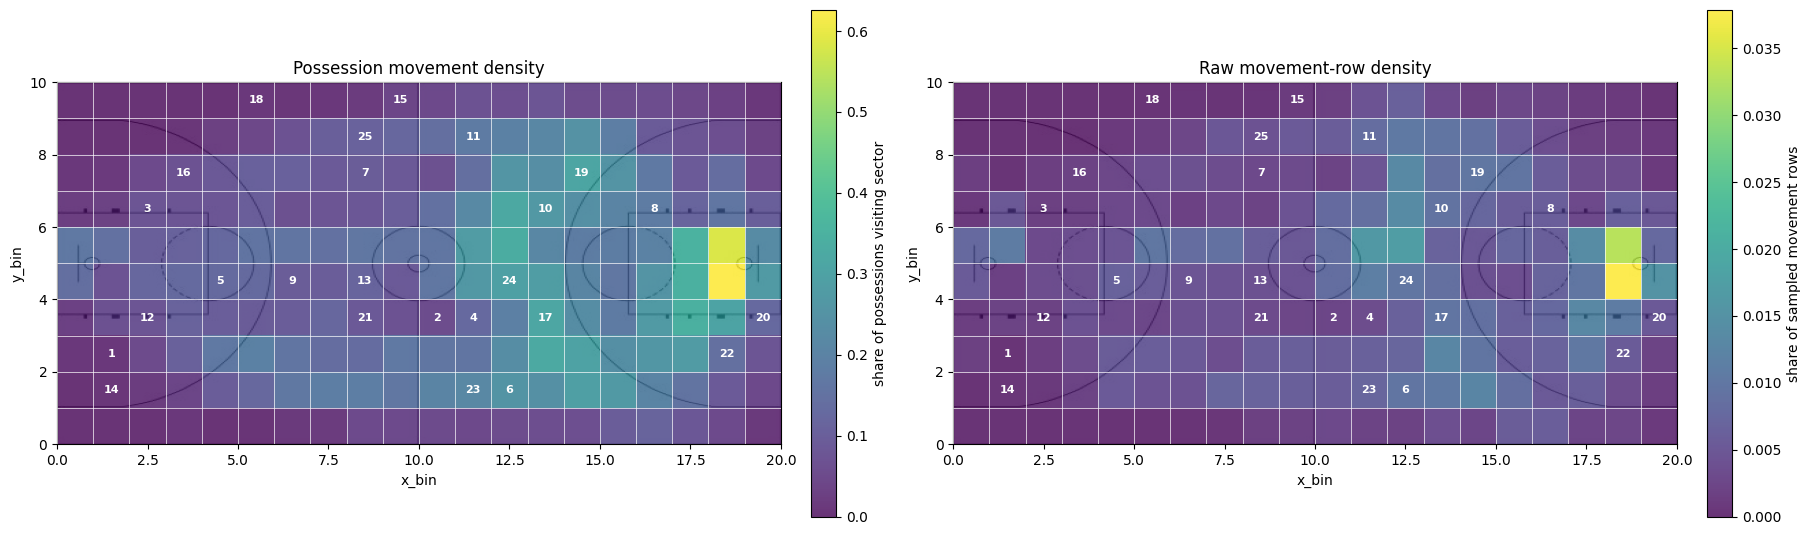

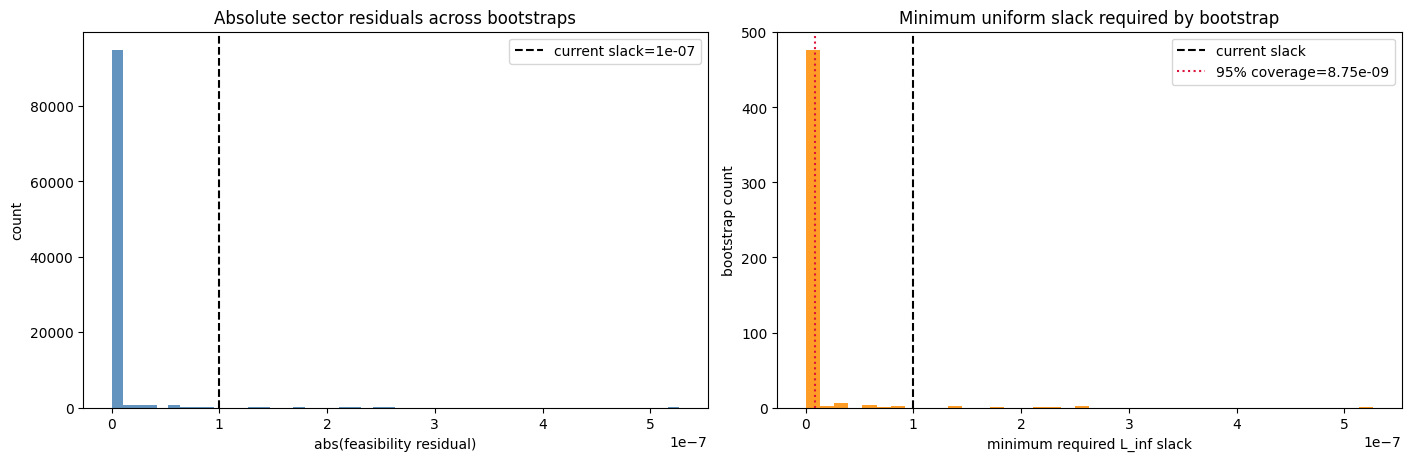

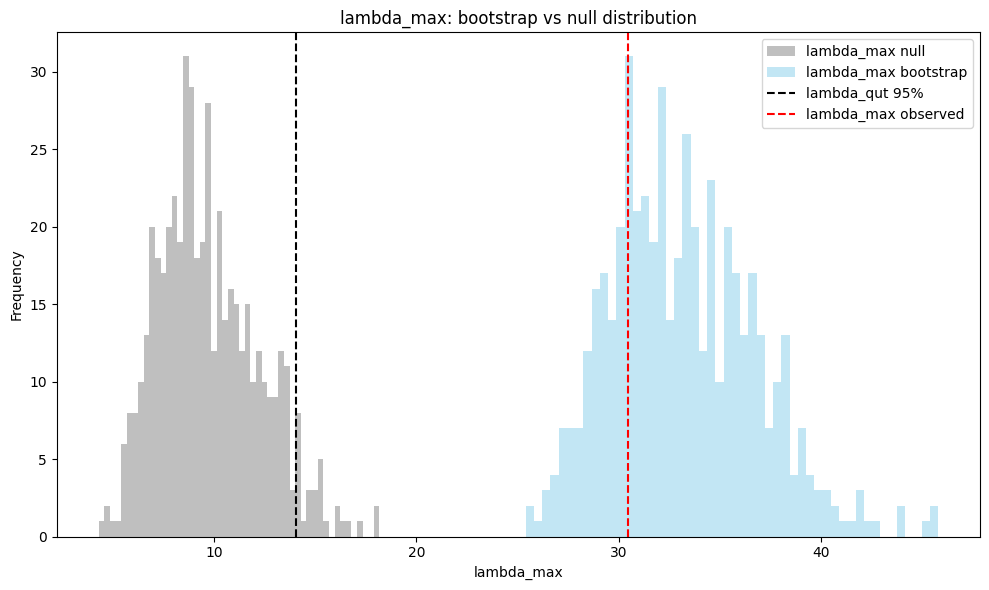

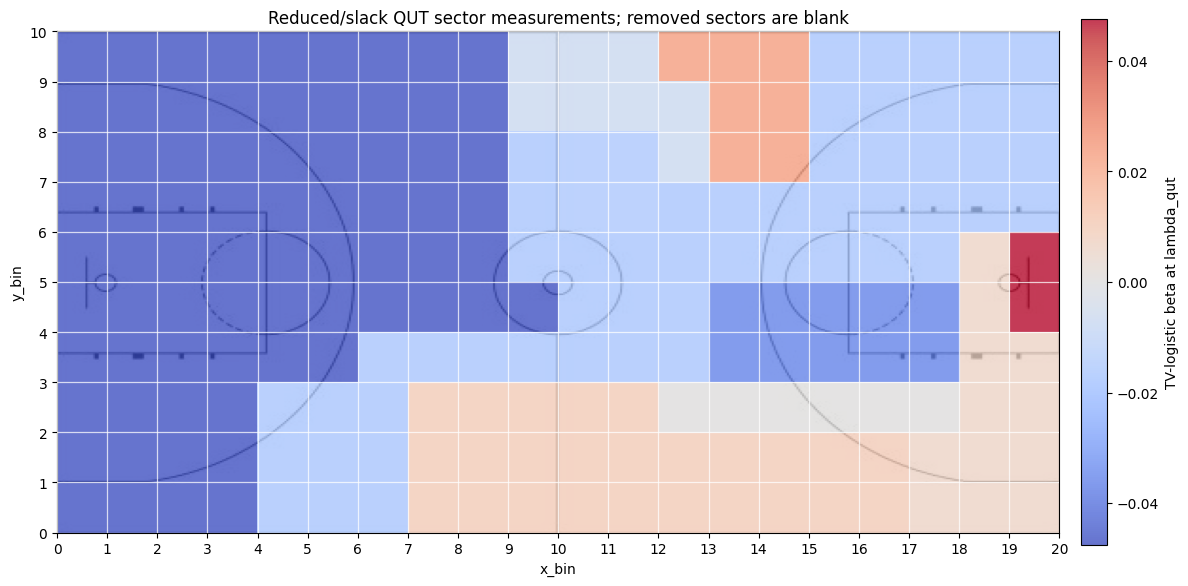

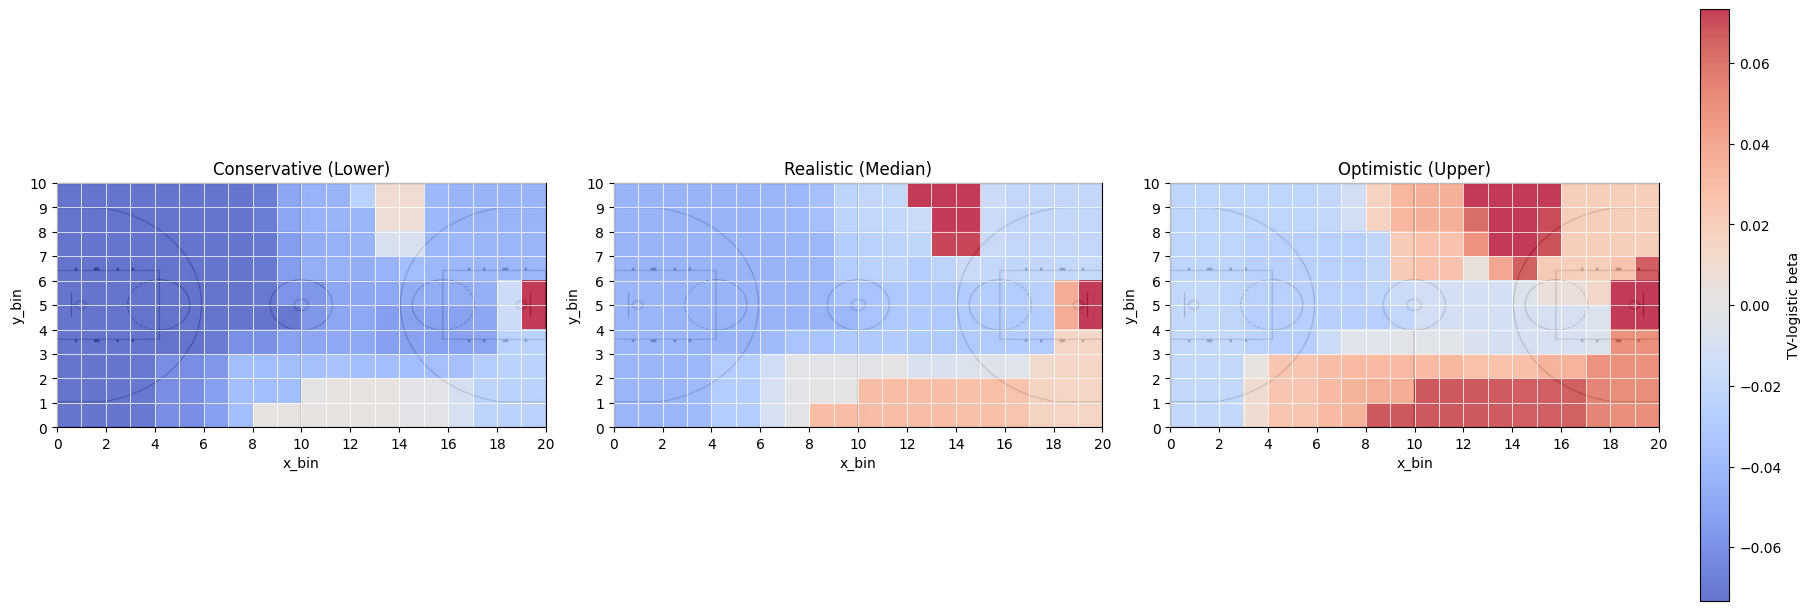

In [1]:
from pathlib import Path

import cvxpy as cp
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import binom
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

import importlib
import funcs
funcs = importlib.reload(funcs)
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
# Input/output assets used by the analysis and court visualizations.
DATA_PATH = Path("Data/analysis_ready_half_court_filtered.csv")
COURT_IMAGE_PATH = Path("court.jpg")
# Monte Carlo and possession-bootstrap settings used to estimate QUT thresholds.
MC_NULL = 500
N_BOOTSTRAPS = 500
N_POSSESSIONS_PER_BOOTSTRAP = 1000
SAMPLES_PER_POSSESSION = 100
MIN_SAMPLES_REQUIRED = 100
BOOTSTRAP_SEED = 43
# Optional diagnostic and pointwise-map outputs.
PLOT_LAMBDA_DISTRIBUTIONS = True
PLOT_POINTWISE_MAPS = True
POINTWISE_ALPHA = 0.05
INFEASIBLE_TOP_N = 25
# Discretized court dimensions: 20 x-bins by 10 y-bins = 200 sectors.
GRID_WIDTH = 20
GRID_HEIGHT = 10
# Feasibility policy: remove clearly infeasible sectors, permit bounded slack for
# small residuals, and penalize that slack strongly in the QUT optimization.
REMOVE_RESIDUAL_TOL = 1e-3
SLACK_TOL = 1e-7
SLACK_PENALTY = 0
FEASIBLE_RESIDUAL_TOL = 1e-7
# Fit the null explicitly with no intercept and no coefficient penalty so the
# projection-on versus projection-off comparison is not confounded by shrinkage.
NULL_LOGISTIC_SOLVER = "lbfgs"
NULL_LOGISTIC_TOL = 1e-12
NULL_LOGISTIC_MAX_ITER = 1000
NULL_PROBABILITY_EPS = 1e-6
# Convex solvers are attempted in this order when a preceding solver is unavailable
# or does not return an optimal solution.
QUT_SOLVERS = ("CLARABEL", "ECOS", "SCS")


# -----------------------------------------------------------------------------
# Data orientation and bootstrap construction
# -----------------------------------------------------------------------------
def orient_qut_bins_left_to_right(
    df,
    court_length=94,
    court_width=50,
    x_bins=GRID_WIDTH,
    y_bins=GRID_HEIGHT,
    possession_col="possession_number",
    time_col="time",
    game_col="game_id",
    period_col="period",
    is_home_col="is_home",
    x_col="x",
    y_col="y",
):
    # Re-bin raw coordinates so all downstream models use the configured grid.
    required_raw_cols = {possession_col, x_col, y_col}
    missing_raw_cols = required_raw_cols - set(df.columns)
    if missing_raw_cols:
        raise ValueError(f"Cannot orient bins without raw columns: {sorted(missing_raw_cols)}")

    out = df.copy()
    out["x_bin"] = np.clip((out[x_col] / court_length * x_bins).astype(int), 0, x_bins - 1)
    out["y_bin"] = np.clip((out[y_col] / court_width * y_bins).astype(int), 0, y_bins - 1)
    out["qut_orientation_flipped"] = False

    # Prefer the known home/away and period-based orientation rule when its
    # identifying columns are available.
    if {game_col, period_col, is_home_col}.issubset(out.columns):
        oriented = funcs.bin_and_flip(
            out,
            court_length=court_length,
            court_width=court_width,
            x_bins=x_bins,
            y_bins=y_bins,
            game_col=game_col,
            period_col=period_col,
            is_home_col=is_home_col,
            x_col=x_col,
            y_col=y_col,
        )
        oriented["qut_orientation_flipped"] = (
            (oriented["x_bin"] != out["x_bin"]) |
            (oriented["y_bin"] != out["y_bin"])
        )
        oriented["qut_orientation_method"] = "funcs.bin_and_flip_home_away_period"
        return oriented

    # Fallback: infer attacking direction from each possession's first and last
    # observed x-bin, then mirror possessions that move right-to-left.
    sort_cols = [possession_col]
    ascending = [True]
    if time_col in out.columns:
        sort_cols.append(time_col)
        ascending.append(False)

    ordered = out.sort_values(sort_cols, ascending=ascending)
    possession_direction = ordered.groupby(possession_col, sort=False)["x_bin"].agg(start="first", end="last")
    flip_possessions = possession_direction.index[possession_direction["end"] < possession_direction["start"]]
    flip_mask = out[possession_col].isin(flip_possessions)

    out.loc[flip_mask, "x_bin"] = (x_bins - 1) - out.loc[flip_mask, "x_bin"]
    out.loc[flip_mask, "y_bin"] = (y_bins - 1) - out.loc[flip_mask, "y_bin"]
    out["qut_orientation_flipped"] = flip_mask.to_numpy()
    out["qut_orientation_method"] = "possession_start_end_inferred"
    return out


# Load the filtered movement data and orient every possession left-to-right before
# any resampling or model fitting, which keeps coefficient maps interpretable.
df_raw = pd.read_csv(DATA_PATH)
df = orient_qut_bins_left_to_right(df_raw)

# Fail early if the columns needed to build the possession-by-sector design matrix
# or binary response are unavailable.
required_cols = {"possession_number", "x_bin", "y_bin", "scored"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

# Summarize the orientation operation as a reproducibility check.
orientation_method = df["qut_orientation_method"].iloc[0]
flipped_possessions = df.loc[df["qut_orientation_flipped"], "possession_number"].nunique()
total_possessions = df["possession_number"].nunique()
orientation_check = (
    df.sort_values(["possession_number", "time"], ascending=[True, False])
      .groupby("possession_number", sort=False)["x_bin"]
      .agg(start="first", end="last")
)
print(f"QUT bin orientation method: {orientation_method}")
print(f"Possessions flipped for left-to-right orientation: {flipped_possessions:,} / {total_possessions:,}")
print(f"Post-orientation mean end-start x_bin: {(orientation_check['end'] - orientation_check['start']).mean():.4f}")

# Resample entire possessions, retaining the within-possession movement structure.
# The first bootstrap is the observed QUT analysis dataset; the remaining samples
# quantify uncertainty in lambda_max and the fitted sector coefficients.
print("Generating Bootstrapped Datasets...")
boot_datasets = funcs.generate_bootstrapped_datasets(
    df,
    n_bootstraps=N_BOOTSTRAPS,
    n_possessions_per_bootstrap=N_POSSESSIONS_PER_BOOTSTRAP,
    samples_per_possession=SAMPLES_PER_POSSESSION,
    min_samples_required=MIN_SAMPLES_REQUIRED,
    seed=BOOTSTRAP_SEED,
)

# Convert the first bootstrap into X (possession-sector visits), y (scored), and
# D_TV (adjacent-sector incidence matrix for total-variation regularization).
df_boot = boot_datasets[0]
X, y, D_TV = funcs.grid(df_boot)
variable_names = [f"x_bin={i // GRID_HEIGHT}, y_bin={i % GRID_HEIGHT}" for i in range(X.shape[1])]


# -----------------------------------------------------------------------------
# Projection-off feasibility diagnostics and visualizations
# -----------------------------------------------------------------------------
def plot_infeasible_variables_on_court(
    top_variables,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Map the largest feasibility residuals back to their physical court sectors.
    plot_df = top_variables.copy()
    plot_df["x_bin"] = plot_df["variable_index"] // grid_height
    plot_df["y_bin"] = plot_df["variable_index"] % grid_height

    # NaN leaves unselected sectors transparent over the court image.
    residual_grid = np.full((grid_width, grid_height), np.nan, dtype=float)
    rank_grid = np.full((grid_width, grid_height), np.nan, dtype=float)
    for rank, row in enumerate(plot_df.itertuples(index=False), start=1):
        residual_grid[int(row.x_bin), int(row.y_bin)] = row.abs_residual
        rank_grid[int(row.x_bin), int(row.y_bin)] = rank

    fig, ax = plt.subplots(figsize=(12, 6))
    court_img = mpimg.imread(court_image_path)
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)

    cmap = plt.colormaps["magma"].copy()
    cmap.set_bad((0, 0, 0, 0))
    sector_map = np.ma.masked_invalid(residual_grid.T)
    im = ax.imshow(
        sector_map,
        origin="lower",
        extent=[0, grid_width, 0, grid_height],
        cmap=cmap,
        alpha=0.78,
        interpolation="nearest",
        zorder=2,
    )

    ax.vlines(
        np.arange(0, grid_width + 1),
        ymin=0,
        ymax=grid_height,
        colors="white",
        linewidth=0.9,
        alpha=0.75,
        zorder=3,
    )
    ax.hlines(
        np.arange(0, grid_height + 1),
        xmin=0,
        xmax=grid_width,
        colors="white",
        linewidth=0.9,
        alpha=0.75,
        zorder=3,
    )

    for row in plot_df.itertuples(index=False):
        rank = int(rank_grid[int(row.x_bin), int(row.y_bin)])
        ax.text(
            row.x_bin + 0.5,
            row.y_bin + 0.5,
            str(rank),
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
            zorder=4,
        )

    ax.set_xlim(0, grid_width)
    ax.set_ylim(0, grid_height)
    ax.set_xticks(np.arange(0, grid_width + 1, 1))
    ax.set_yticks(np.arange(0, grid_height + 1, 1))
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    ax.set_title(f"Top {len(plot_df)} projection-off infeasibility sectors")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("abs residual from nearest feasible grad_h")
    plt.tight_layout()
    return fig, ax, plot_df


def build_movement_density_diagnostics(
    df_model,
    X_model,
    y_model,
    feasibility_diagnostics,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Combine design-matrix visit counts, raw movement density, scoring rates, and
    # null-gradient feasibility residuals into one row per court sector.
    n_sectors = grid_width * grid_height
    variable_index = np.arange(n_sectors)
    possession_visits = np.asarray(X_model.sum(axis=0)).reshape(-1)
    scored_visits = np.asarray(X_model.T @ y_model).reshape(-1)
    movement_rows = (
        df_model.groupby(["x_bin", "y_bin"]).size()
        .reindex(pd.MultiIndex.from_product([range(grid_width), range(grid_height)]), fill_value=0)
        .to_numpy(dtype=float)
    )

    sector_density = pd.DataFrame({
        "variable_index": variable_index,
        "x_bin": variable_index // grid_height,
        "y_bin": variable_index % grid_height,
        "possession_visits": possession_visits.astype(int),
        "possession_visit_rate": possession_visits / X_model.shape[0],
        "movement_rows": movement_rows.astype(int),
        "movement_row_share": movement_rows / max(float(movement_rows.sum()), 1.0),
        "scoring_rate_when_visited": np.divide(
            scored_visits,
            possession_visits,
            out=np.full(n_sectors, np.nan, dtype=float),
            where=possession_visits > 0,
        ),
        "grad_h": np.asarray(feasibility_diagnostics["grad_h"], dtype=float),
        "nearest_feasible_grad_h": np.asarray(feasibility_diagnostics["nearest_feasible_grad_h"], dtype=float),
        "residual": np.asarray(feasibility_diagnostics["residual"], dtype=float),
    })
    sector_density["abs_residual"] = sector_density["residual"].abs()

    # Compare each sector with its four-neighbor court adjacency to determine
    # whether infeasibility coincides with sharp local gradient or density changes.
    grad_grid = sector_density["grad_h"].to_numpy().reshape(grid_width, grid_height)
    density_grid = sector_density["possession_visit_rate"].to_numpy().reshape(grid_width, grid_height)
    mean_grad_jump = np.zeros(n_sectors, dtype=float)
    max_grad_jump = np.zeros(n_sectors, dtype=float)
    mean_density_jump = np.zeros(n_sectors, dtype=float)
    for idx, row in sector_density.iterrows():
        x_bin, y_bin = int(row.x_bin), int(row.y_bin)
        neighbors = [
            (nx, ny)
            for nx, ny in ((x_bin - 1, y_bin), (x_bin + 1, y_bin), (x_bin, y_bin - 1), (x_bin, y_bin + 1))
            if 0 <= nx < grid_width and 0 <= ny < grid_height
        ]
        grad_jumps = [abs(grad_grid[x_bin, y_bin] - grad_grid[nx, ny]) for nx, ny in neighbors]
        density_jumps = [abs(density_grid[x_bin, y_bin] - density_grid[nx, ny]) for nx, ny in neighbors]
        mean_grad_jump[idx] = np.mean(grad_jumps)
        max_grad_jump[idx] = np.max(grad_jumps)
        mean_density_jump[idx] = np.mean(density_jumps)

    sector_density["mean_adjacent_abs_grad_h_difference"] = mean_grad_jump
    sector_density["max_adjacent_abs_grad_h_difference"] = max_grad_jump
    sector_density["mean_adjacent_abs_density_difference"] = mean_density_jump
    return sector_density


def plot_movement_density_heatmaps(
    sector_density,
    highlighted_variables,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Display possession-level and raw-row density side by side; ranked labels mark
    # the sectors with the largest projection-off feasibility residuals.
    court_img = mpimg.imread(court_image_path)
    panels = [
        ("possession_visit_rate", "Possession movement density", "share of possessions visiting sector"),
        ("movement_row_share", "Raw movement-row density", "share of sampled movement rows"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
    highlighted = set(highlighted_variables["variable_index"].astype(int))

    for ax, (column, title, colorbar_label) in zip(axes, panels):
        values = sector_density[column].to_numpy().reshape(grid_width, grid_height)
        ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)
        im = ax.imshow(
            values.T, origin="lower", extent=[0, grid_width, 0, grid_height],
            cmap="viridis", alpha=0.80, interpolation="nearest", zorder=2,
        )
        for rank, variable in enumerate(highlighted_variables["variable_index"].astype(int), start=1):
            x_bin, y_bin = variable // grid_height, variable % grid_height
            ax.text(x_bin + 0.5, y_bin + 0.5, str(rank), ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=4)
        ax.vlines(np.arange(grid_width + 1), 0, grid_height, colors="white", linewidth=0.7, alpha=0.70, zorder=3)
        ax.hlines(np.arange(grid_height + 1), 0, grid_width, colors="white", linewidth=0.7, alpha=0.70, zorder=3)
        ax.set(xlim=(0, grid_width), ylim=(0, grid_height), xlabel="x_bin", ylabel="y_bin", title=title)
        fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label=colorbar_label)

    return fig, axes


def build_infeasible_neighbor_comparison(
    sector_density,
    highlighted_variables,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Produce a long-form table comparing each highlighted sector with its valid
    # left, right, lower, and upper neighbors.
    lookup = sector_density.set_index(["x_bin", "y_bin"])
    rows = []
    directions = (("left", -1, 0), ("right", 1, 0), ("down", 0, -1), ("up", 0, 1))

    for rank, focal in enumerate(highlighted_variables.itertuples(index=False), start=1):
        focal_idx = int(focal.variable_index)
        focal_x, focal_y = focal_idx // grid_height, focal_idx % grid_height
        focal_values = lookup.loc[(focal_x, focal_y)]
        candidates = [("focal", focal_x, focal_y)] + [
            (direction, focal_x + dx, focal_y + dy)
            for direction, dx, dy in directions
            if 0 <= focal_x + dx < grid_width and 0 <= focal_y + dy < grid_height
        ]
        for direction, x_bin, y_bin in candidates:
            values = lookup.loc[(x_bin, y_bin)]
            rows.append({
                "infeasible_rank": rank,
                "focal_variable_index": focal_idx,
                "focal_sector": f"({focal_x}, {focal_y})",
                "relation": direction,
                "x_bin": x_bin,
                "y_bin": y_bin,
                "possession_visits": int(values["possession_visits"]),
                "possession_visit_rate": values["possession_visit_rate"],
                "movement_rows": int(values["movement_rows"]),
                "scoring_rate_when_visited": values["scoring_rate_when_visited"],
                "grad_h": values["grad_h"],
                "grad_h_difference_from_focal": values["grad_h"] - focal_values["grad_h"],
                "residual": values["residual"],
                "abs_residual": values["abs_residual"],
            })

    return pd.DataFrame(rows)


def summarize_infeasibility_hypotheses(sector_density, feasibility_diagnostics):
    # Test whether residual magnitude is associated with sparse movement coverage or
    # abrupt neighboring gradients, while guarding against constant input columns.
    residual = sector_density["residual"].to_numpy(dtype=float)
    def safe_spearman(left, right):
        valid = pd.concat([left, right], axis=1).dropna()
        if len(valid) < 2 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
            return np.nan
        return valid.iloc[:, 0].corr(valid.iloc[:, 1], method="spearman")

    summary = pd.Series({
        "sum_grad_h": sector_density["grad_h"].sum(),
        "residual_mean": residual.mean(),
        "residual_std": residual.std(),
        "residual_range": np.ptp(residual),
        "spearman_abs_residual_vs_possession_density": safe_spearman(sector_density["abs_residual"], sector_density["possession_visit_rate"]),
        "spearman_abs_residual_vs_adjacent_grad_jump": safe_spearman(sector_density["abs_residual"], sector_density["mean_adjacent_abs_grad_h_difference"]),
    }, name="value")
    uniform_tol = max(FEASIBLE_RESIDUAL_TOL, 1e-6 * max(float(np.max(np.abs(residual))), 1.0))
    if np.ptp(residual) <= uniform_tol and feasibility_diagnostics["rank_D_transpose"] == len(residual) - 1:
        print("Interpretation: the feasibility residual is spatially uniform. For this connected TV incidence matrix,")
        print("that indicates a global zero-sum/numerical mismatch in grad_h, not a localized density gap or adjacent-sector jump.")
    else:
        print("Interpretation: residuals vary spatially; inspect the density correlations and neighbor table below.")
    return summary


# -----------------------------------------------------------------------------
# Null logistic model and gradient-feasibility analysis
# -----------------------------------------------------------------------------
def fit_null_logistic_regression(X_model, y_model):
    """Fit the project-standard no-intercept logistic null model for beta0."""
    # Under the TV null all sector coefficients equal beta0. Collapsing X into X0
    # therefore makes each predictor the number of sectors visited in a possession.
    X0 = X_model @ np.ones((X_model.shape[1], 1), dtype=float)
    X0 = np.asarray(X0, dtype=float)
    y_array = np.asarray(y_model).reshape(-1)
    if X0.shape[0] != y_array.shape[0]:
        raise ValueError("X_model and y_model have incompatible row counts.")
    if not np.isfinite(X0).all() or not np.isfinite(y_array).all():
        raise ValueError("The null logistic regression received non-finite data.")
    if np.unique(y_array).size < 2:
        raise ValueError("The null logistic regression requires both outcome classes.")

    # Fit the one-feature null explicitly. penalty=None is essential here: an L2
    # penalty would alter beta0 and grad_h, changing the projection comparison.
    null_model = LogisticRegression(
        fit_intercept=False,
        solver=NULL_LOGISTIC_SOLVER,
        penalty=None,
        tol=NULL_LOGISTIC_TOL,
        max_iter=NULL_LOGISTIC_MAX_ITER,
    )
    null_model.fit(X0, y_array)
    beta0 = float(null_model.coef_.reshape(-1)[0])

    # Expand beta0 back to the common sector-coefficient vector used by the QUT
    # derivation, then compute and clip the associated Bernoulli probabilities.
    u0 = beta0 * np.ones(X_model.shape[1], dtype=float)
    linear_predictor = np.asarray(X_model @ u0).reshape(-1)
    probabilities = 1.0 / (1.0 + np.exp(-linear_predictor))
    probabilities = np.clip(
        probabilities, NULL_PROBABILITY_EPS, 1.0 - NULL_PROBABILITY_EPS
    )

    # For the unpenalized fit, this likelihood score should be numerically near zero.
    likelihood_score = float(X0.reshape(-1) @ (y_array - probabilities))
    return {
        "beta0": beta0,
        "probabilities": probabilities,
        "likelihood_score": likelihood_score,
        "X0": X0,
        "u0": u0,
        "penalty": null_model.penalty,
        "solver": null_model.solver,
        "n_iter": int(null_model.n_iter_[0]),
        "model": null_model,
    }


def compute_null_probabilities(X_model, y_model):
    # Return fitted Bernoulli probabilities under the common-coefficient null.
    return fit_null_logistic_regression(X_model, y_model)["probabilities"]


def compute_grad_h(X_model, y_model):
    # Evaluate X.T @ (y - p0), the likelihood gradient used by the QUT dual solve.
    p = compute_null_probabilities(X_model, y_model)
    return np.asarray(X_model.T @ (y_model - p)).reshape(-1)


def diagnose_null_logistic_feasibility(
    y_model,
    X_model,
    D_model,
    variable_names=None,
    top_n=15,
    grid_height=GRID_HEIGHT,
):
    # Fit beta0 and determine whether grad_h lies in the column space of D.T.
    # The least-squares residual measures the part that the TV dual cannot represent.
    null_fit = fit_null_logistic_regression(X_model, y_model)
    grad_h = np.asarray(X_model.T @ (y_model - null_fit["probabilities"])).reshape(-1)
    A = np.asarray(D_model.T, dtype=float)
    nearest_w, *_ = np.linalg.lstsq(A, grad_h, rcond=None)
    nearest_grad_h = A @ nearest_w
    residual = grad_h - nearest_grad_h
    abs_residual = np.abs(residual)
    order = np.argsort(abs_residual)[::-1][:top_n]

    if variable_names is None:
        variable_names = [
            f"x_bin={i // grid_height}, y_bin={i % grid_height}"
            for i in range(X_model.shape[1])
        ]

    top_variables = pd.DataFrame({
        "variable_index": order,
        "variable": [variable_names[i] for i in order],
        "grad_h": grad_h[order],
        "nearest_feasible_grad_h": nearest_grad_h[order],
        "residual": residual[order],
        "abs_residual": abs_residual[order],
    })
    return {
        "top_variables": top_variables,
        "grad_h": grad_h,
        "nearest_feasible_grad_h": nearest_grad_h,
        "residual": residual,
        "residual_l2": float(np.linalg.norm(residual)),
        "residual_linf": float(np.max(abs_residual)),
        "rank_D_transpose": int(np.linalg.matrix_rank(A)),
        "n_variables": int(X_model.shape[1]),
        "null_fit": null_fit,
        "grad_h_sum": float(grad_h.sum()),
        "constant_offset": float(grad_h.mean()),
    }


# -----------------------------------------------------------------------------
# Reduced/slack QUT optimization
# -----------------------------------------------------------------------------
def build_reduced_qut_system(
    X_full,
    D_full,
    diagnostics,
    remove_residual_tol=REMOVE_RESIDUAL_TOL,
    feasible_residual_tol=FEASIBLE_RESIDUAL_TOL,
    grid_height=GRID_HEIGHT,
):
    # Remove sectors whose feasibility residual exceeds the hard tolerance. Sectors
    # with smaller nonzero residuals remain available to the bounded-slack model.
    residual = np.asarray(diagnostics["residual"], dtype=float)
    abs_residual = np.abs(residual)
    variable_index = np.arange(X_full.shape[1])
    remove_mask = abs_residual > remove_residual_tol
    keep_mask = ~remove_mask

    if not keep_mask.any():
        raise ValueError("All sectors were marked for removal. Increase REMOVE_RESIDUAL_TOL or inspect the data.")

    # Remove TV edges incident to deleted sectors so the reduced incidence matrix
    # and reduced design matrix refer to the same coefficient vector.
    D_array = np.asarray(D_full, dtype=float)
    edge_keep_mask = np.ones(D_array.shape[0], dtype=bool)
    if remove_mask.any():
        edge_keep_mask = np.all(D_array[:, remove_mask] == 0, axis=1)

    X_reduced = X_full[:, keep_mask]
    D_reduced = D_array[edge_keep_mask][:, keep_mask]
    keep_indices = variable_index[keep_mask]

    sector_status = pd.DataFrame({
        "variable_index": variable_index,
        "x_bin": variable_index // grid_height,
        "y_bin": variable_index % grid_height,
        "residual": residual,
        "abs_residual": abs_residual,
        "qut_included": keep_mask,
        "measurement_available": keep_mask,
    })
    sector_status["qut_action"] = np.select(
        [
            remove_mask,
            keep_mask & (abs_residual > feasible_residual_tol),
        ],
        ["remove_no_measurement", "keep_with_slack"],
        default="keep_exact",
    )

    return {
        "X_reduced": X_reduced,
        "D_reduced": D_reduced,
        "keep_mask": keep_mask,
        "remove_mask": remove_mask,
        "edge_keep_mask": edge_keep_mask,
        "keep_indices": keep_indices,
        "sector_status": sector_status,
    }


def solve_problem_with_fallback(problem, solvers=QUT_SOLVERS):
    # Try the configured convex solvers sequentially and accept the first optimal
    # or optimal-inaccurate result.
    last_error = None
    for solver in solvers:
        try:
            problem.solve(solver=solver, verbose=False)
        except Exception as exc:
            last_error = exc
            continue

        if problem.status in {"optimal", "optimal_inaccurate"}:
            return solver
        last_error = RuntimeError(f"{solver} returned status {problem.status}")

    raise RuntimeError(f"All solvers failed. Last error: {last_error}")


def solve_infinity_norm_with_slack(
    y_model,
    X_model,
    D_model,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Solve D.T @ w + slack = grad_h. The infinity norm of w is lambda_max,
    # while an L1 penalty discourages use of the explicitly bounded slack vector.
    grad_h = compute_grad_h(X_model, y_model)
    w = cp.Variable(D_model.shape[0])
    slack = cp.Variable(X_model.shape[1])
    constraints = [D_model.T @ w + slack == grad_h]
    if slack_tol is not None:
        constraints.extend([slack <= slack_tol, slack >= -slack_tol])

    objective = cp.Minimize(cp.norm(w, "inf") + slack_penalty * cp.norm1(slack))
    problem = cp.Problem(objective, constraints)
    solver_used = solve_problem_with_fallback(problem)

    if problem.status not in {"optimal", "optimal_inaccurate"}:
        raise ValueError(f"Slack optimization failed. Status: {problem.status}")

    lambda_value = float(np.max(np.abs(w.value)))
    return w.value, lambda_value, slack.value, grad_h, solver_used


def lambda_qut_with_slack(
    X_model,
    y_model,
    D_model,
    MC=MC_NULL,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Simulate Bernoulli responses from the fitted null and compute lambda_max for
    # every valid simulation; their 95th percentile defines lambda_qut.
    p0 = compute_null_probabilities(X_model, y_model)
    lambdas = []
    null_slack_linf = []
    attempts = 0

    print("Simulating null responses with reduced/slack QUT model...")
    while len(lambdas) < MC and attempts < MC * 20:
        attempts += 1
        y_sim = binom.rvs(1, p0)
        if np.all(y_sim == 0) or np.all(y_sim == 1):
            continue

        try:
            _, lambda_val, slack_val, _, _ = solve_infinity_norm_with_slack(
                y_sim,
                X_model,
                D_model,
                slack_tol=slack_tol,
                slack_penalty=slack_penalty,
            )
        except Exception as exc:
            print(f"Skipping simulation due to error: {exc}")
            continue

        lambdas.append(lambda_val)
        null_slack_linf.append(float(np.max(np.abs(slack_val))))
        if len(lambdas) % 100 == 0:
            print(f"Accepted {len(lambdas)} / {MC} simulations")

    if not lambdas:
        raise RuntimeError("All reduced/slack QUT simulations failed.")

    # Evaluate the same dual problem on the observed bootstrap response so its
    # lambda_max can be compared directly with the simulated null distribution.
    _, lambda_max_obs, observed_slack, _, observed_solver = solve_infinity_norm_with_slack(
        y_model,
        X_model,
        D_model,
        slack_tol=slack_tol,
        slack_penalty=slack_penalty,
    )
    lambda_qut_val = float(np.quantile(lambdas, 0.95))

    print(f"lambda_qut (95th percentile null): {lambda_qut_val:.4f}")
    print(f"lambda_max (data): {lambda_max_obs:.4f}")
    print(f"observed slack L_inf: {np.max(np.abs(observed_slack)):.6g}")
    print(f"observed solve solver: {observed_solver}")
    return lambda_qut_val, lambda_max_obs, np.asarray(lambdas), observed_slack, np.asarray(null_slack_linf), observed_solver


def compute_lambda_max_from_bootstraps_with_slack(
    boot_datasets,
    qut_system,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Recompute observed-style lambda_max values over the remaining possession
    # bootstraps while preserving the sector mask selected from the first bootstrap.
    rows = []
    keep_mask = qut_system["keep_mask"]
    D_reduced = qut_system["D_reduced"]

    for bootstrap_index, df_b in enumerate(tqdm(boot_datasets, desc="Computing lambda_max for bootstraps"), start=1):
        X_b, y_b, _ = funcs.grid(df_b)
        X_b_reduced = X_b[:, keep_mask]

        try:
            _, lambda_max_b, slack_b, _, solver_b = solve_infinity_norm_with_slack(
                y_b,
                X_b_reduced,
                D_reduced,
                slack_tol=slack_tol,
                slack_penalty=slack_penalty,
            )
        except Exception as exc:
            rows.append({
                "bootstrap_index": bootstrap_index,
                "lambda_max": np.nan,
                "slack_linf": np.nan,
                "solver": None,
                "error": str(exc),
            })
            continue

        rows.append({
            "bootstrap_index": bootstrap_index,
            "lambda_max": lambda_max_b,
            "slack_linf": float(np.max(np.abs(slack_b))),
            "solver": solver_b,
            "error": None,
        })

    return pd.DataFrame(rows)


def summarize_lambda_max_bootstrap_analysis(
    lambda_max_obs,
    lambda_max_null,
    lambda_max_bootstrap,
    plot=True,
):
    # Report the null QUT cutoff, observed statistic, bootstrap uncertainty interval,
    # and empirical upper-tail null probability.
    lambda_max_null = np.asarray(lambda_max_null, dtype=float)
    lambda_max_bootstrap = np.asarray(lambda_max_bootstrap, dtype=float)
    lambda_qut_summary = float(np.percentile(lambda_max_null, 95))
    ci_lower, ci_upper = np.quantile(lambda_max_bootstrap, [0.025, 0.975])
    p_value = float(np.mean(lambda_max_null >= lambda_max_obs))

    print(f"lambda_qut (95th percentile null): {lambda_qut_summary:.4f}")
    print(f"lambda_max (observed): {lambda_max_obs:.4f}")
    print(f"95% CI for lambda_max (bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Empirical p-value (lambda_max > lambda_qut): {p_value:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(lambda_max_null, bins=50, alpha=0.5, label="lambda_max null", color="gray")
        ax.hist(lambda_max_bootstrap, bins=50, alpha=0.5, label="lambda_max bootstrap", color="skyblue")
        ax.axvline(lambda_qut_summary, color="black", linestyle="--", label="lambda_qut 95%")
        ax.axvline(lambda_max_obs, color="red", linestyle="--", label="lambda_max observed")
        ax.set_xlabel("lambda_max")
        ax.set_ylabel("Frequency")
        ax.set_title("lambda_max: bootstrap vs null distribution")
        ax.legend()
        plt.tight_layout()

    return {
        "lambda_qut": lambda_qut_summary,
        "lambda_max_obs": float(lambda_max_obs),
        "ci": (float(ci_lower), float(ci_upper)),
        "p_value": p_value,
    }


# -----------------------------------------------------------------------------
# Penalized logistic coefficient estimation and court-map construction
# -----------------------------------------------------------------------------
def fit_reduced_tv_logistic(X_model, y_model, D_model, lambda_tv):
    # Fit sector coefficients with Bernoulli negative log-likelihood plus an L1
    # total-variation penalty that encourages adjacent sectors to share effects.
    beta = cp.Variable(X_model.shape[1])
    logits = X_model @ beta
    loss = cp.sum(cp.logistic(logits) - cp.multiply(y_model, logits))
    penalty = lambda_tv * cp.norm1(D_model @ beta)
    problem = cp.Problem(cp.Minimize(loss + penalty))
    solver_used = solve_problem_with_fallback(problem)
    if problem.status not in {"optimal", "optimal_inaccurate"}:
        raise ValueError(f"Reduced TV logistic fit failed. Status: {problem.status}")
    return np.asarray(beta.value).reshape(-1), solver_used


def map_reduced_values_to_grid(values_reduced, keep_indices, grid_width=GRID_WIDTH, grid_height=GRID_HEIGHT):
    # Restore retained coefficients to the full 20 x 10 grid; removed sectors stay
    # NaN so plots correctly show that no measurement is available there.
    full_values = np.full(grid_width * grid_height, np.nan, dtype=float)
    full_values[keep_indices] = values_reduced
    return full_values.reshape(grid_width, grid_height)


def plot_qut_measurements_on_court(
    measurement_grid,
    sector_status,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Overlay fitted beta values on the court and mark removed sectors with X.
    fig, ax = plt.subplots(figsize=(12, 6))
    court_img = mpimg.imread(court_image_path)
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)

    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad((0, 0, 0, 0))
    finite_vals = measurement_grid[np.isfinite(measurement_grid)]
    vmax = float(np.percentile(np.abs(finite_vals), 95)) if len(finite_vals) else 1.0
    vmax = max(vmax, 1e-6)
    im = ax.imshow(
        np.ma.masked_invalid(measurement_grid.T),
        origin="lower",
        extent=[0, grid_width, 0, grid_height],
        cmap=cmap,
        alpha=0.78,
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax,
        zorder=2,
    )

    removed = sector_status[~sector_status["measurement_available"]]
    for row in removed.itertuples(index=False):
        ax.text(row.x_bin + 0.5, row.y_bin + 0.5, "X", ha="center", va="center", color="black", fontsize=9, fontweight="bold", zorder=4)

    ax.vlines(np.arange(0, grid_width + 1), ymin=0, ymax=grid_height, colors="white", linewidth=0.9, alpha=0.75, zorder=3)
    ax.hlines(np.arange(0, grid_height + 1), xmin=0, xmax=grid_width, colors="white", linewidth=0.9, alpha=0.75, zorder=3)
    ax.set_xlim(0, grid_width)
    ax.set_ylim(0, grid_height)
    ax.set_xticks(np.arange(0, grid_width + 1, 1))
    ax.set_yticks(np.arange(0, grid_height + 1, 1))
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    ax.set_title("Reduced/slack QUT sector measurements; removed sectors are blank")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("TV-logistic beta at lambda_qut")
    plt.tight_layout()
    return fig, ax


def bootstrap_reduced_percentile_maps_fixed_lambda(
    boot_datasets,
    qut_system,
    lambda_tv,
    alpha=POINTWISE_ALPHA,
):
    # Refit the TV-logistic model to every bootstrap using the same lambda_qut and
    # sector mask, producing a comparable coefficient surface from each sample.
    maps = []
    failures = []
    keep_mask = qut_system["keep_mask"]
    keep_indices = qut_system["keep_indices"]
    D_reduced = qut_system["D_reduced"]

    for bootstrap_index, df_b in enumerate(tqdm(boot_datasets, desc="Pointwise maps at fixed lambda"), start=1):
        X_b, y_b, _ = funcs.grid(df_b)
        X_b_reduced = X_b[:, keep_mask]
        try:
            beta_b, solver_b = fit_reduced_tv_logistic(
                X_b_reduced,
                y_b,
                D_reduced,
                lambda_tv=lambda_tv,
            )
        except Exception as exc:
            failures.append({"bootstrap_index": bootstrap_index, "error": str(exc)})
            continue

        maps.append(map_reduced_values_to_grid(beta_b, keep_indices))

    if not maps:
        raise RuntimeError("All pointwise bootstrap map fits failed.")

    # Convert the bootstrap surfaces into lower, median, and upper pointwise maps.
    maps_all = np.stack(maps)
    q_lo, q_hi = alpha / 2, 1 - alpha / 2
    beta_lo = np.nanquantile(maps_all, q_lo, axis=0)
    beta_med = np.nanmedian(maps_all, axis=0)
    beta_hi = np.nanquantile(maps_all, q_hi, axis=0)

    removed_mask = ~qut_system["keep_mask"]
    if removed_mask.any():
        removed_grid = removed_mask.reshape(GRID_WIDTH, GRID_HEIGHT)
        beta_lo[removed_grid] = np.nan
        beta_med[removed_grid] = np.nan
        beta_hi[removed_grid] = np.nan
        maps_all[:, removed_grid] = np.nan

    return beta_med, beta_lo, beta_hi, maps_all, pd.DataFrame(failures)


def plot_pointwise_measurement_maps(
    beta_lo,
    beta_med,
    beta_hi,
    sector_status,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Plot conservative, typical, and optimistic coefficient measurements with one
    # shared symmetric color scale so the three surfaces are visually comparable.
    maps = [beta_lo, beta_med, beta_hi]
    titles = ["Conservative (Lower)", "Realistic (Median)", "Optimistic (Upper)"]
    finite_chunks = [m[np.isfinite(m)] for m in maps if np.isfinite(m).any()]
    finite_vals = np.concatenate(finite_chunks) if finite_chunks else np.asarray([1.0])
    vmax = max(float(np.percentile(np.abs(finite_vals), 95)), 1e-6)
    court_img = mpimg.imread(court_image_path)
    removed = sector_status[~sector_status["measurement_available"]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad((0, 0, 0, 0))

    for ax, data, title in zip(axes, maps, titles):
        ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)
        im = ax.imshow(
            np.ma.masked_invalid(data.T),
            origin="lower",
            extent=[0, grid_width, 0, grid_height],
            cmap=cmap,
            alpha=0.78,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
            zorder=2,
        )
        for row in removed.itertuples(index=False):
            ax.text(row.x_bin + 0.5, row.y_bin + 0.5, "X", ha="center", va="center", color="black", fontsize=8, fontweight="bold", zorder=4)

        ax.vlines(np.arange(0, grid_width + 1), ymin=0, ymax=grid_height, colors="white", linewidth=0.7, alpha=0.75, zorder=3)
        ax.hlines(np.arange(0, grid_height + 1), xmin=0, xmax=grid_width, colors="white", linewidth=0.7, alpha=0.75, zorder=3)
        ax.set_xlim(0, grid_width)
        ax.set_ylim(0, grid_height)
        ax.set_xticks(np.arange(0, grid_width + 1, 2))
        ax.set_yticks(np.arange(0, grid_height + 1, 1))
        ax.set_xlabel("x_bin")
        ax.set_ylabel("y_bin")
        ax.set_title(title)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("TV-logistic beta")
    return fig, axes

# -----------------------------------------------------------------------------
# Execute the end-to-end analysis
# -----------------------------------------------------------------------------
# Display basic data and matrix diagnostics before starting costly optimization.
print(f"Loaded {len(df):,} source rows from {DATA_PATH}")
print(f"Source possessions: {df['possession_number'].nunique():,}")
print(f"Bootstrap datasets: {len(boot_datasets):,}")
print(f"QUT bootstrap rows: {len(df_boot):,}")
print(f"QUT bootstrap possessions: {df_boot['possession_number'].nunique():,}")
print(f"X shape: {X.shape}; D_TV shape: {D_TV.shape}; scored rate: {y.mean():.4f}")
print("grad_h projection is OFF for this QUT run.")

# Fit the scalar null coefficient beta0 and diagnose projection-off TV feasibility.
diagnostics = diagnose_null_logistic_feasibility(
    y, X, D_TV,
    variable_names=variable_names,
    top_n=X.shape[1],
)

print(f"null beta0: {diagnostics['null_fit']['beta0']:.12g}")
print(f"null penalty: {diagnostics['null_fit']['penalty']}")
print(f"null optimizer iterations: {diagnostics['null_fit']['n_iter']}")
print(f"null likelihood score: {diagnostics['null_fit']['likelihood_score']:.6g}")
print(f"sum(grad_h): {diagnostics['grad_h_sum']:.6g}")
print(f"non-representable constant offset: {diagnostics['constant_offset']:.6g}")
print(
    "Distance from grad_h to col(D_TV.T): "
    f"L2={diagnostics['residual_l2']:.6g}, "
    f"Linf={diagnostics['residual_linf']:.6g}"
)
print(
    f"rank(D_TV.T)={diagnostics['rank_D_transpose']} / "
    f"{diagnostics['n_variables']} variables"
)
display(diagnostics["top_variables"].head(INFEASIBLE_TOP_N))
fig, ax, infeasible_plot_variables = plot_infeasible_variables_on_court(
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N)
)
display(infeasible_plot_variables[["variable_index", "x_bin", "y_bin", "residual", "abs_residual"]])

# Investigate whether any infeasibility is explained by movement density or sharp
# spatial changes, then display sector-level and neighbor-level evidence.
sector_density_diagnostics = build_movement_density_diagnostics(
    df_boot, X, y, diagnostics
)
plot_movement_density_heatmaps(
    sector_density_diagnostics,
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N),
)
infeasible_neighbor_comparison = build_infeasible_neighbor_comparison(
    sector_density_diagnostics,
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N),
)
infeasibility_hypothesis_summary = summarize_infeasibility_hypotheses(
    sector_density_diagnostics, diagnostics
)
display(infeasibility_hypothesis_summary.to_frame())
display(
    infeasible_neighbor_comparison.style.format({
        "possession_visit_rate": "{:.2%}",
        "scoring_rate_when_visited": "{:.3f}",
        "grad_h": "{:.6g}",
        "grad_h_difference_from_focal": "{:+.6g}",
        "residual": "{:.3g}",
        "abs_residual": "{:.3g}",
    })
)

# Apply the hard-removal/bounded-slack feasibility policy and report the resulting
# reduced coefficient and TV-edge dimensions.
qut_system = build_reduced_qut_system(
    X,
    D_TV,
    diagnostics,
    remove_residual_tol=REMOVE_RESIDUAL_TOL,
    feasible_residual_tol=FEASIBLE_RESIDUAL_TOL,
)
sector_status = qut_system["sector_status"]
removed_sectors = sector_status[~sector_status["measurement_available"]]
slack_sectors = sector_status[sector_status["qut_action"] == "keep_with_slack"]

print(f"Removed sectors with no final measurement: {len(removed_sectors)}")
print(f"Kept sectors using bounded slack: {len(slack_sectors)}")
print(f"Kept sectors in QUT model: {qut_system['X_reduced'].shape[1]} / {X.shape[1]}")
print(f"Kept TV edges in QUT model: {qut_system['D_reduced'].shape[0]} / {D_TV.shape[0]}")
display(sector_status.sort_values("abs_residual", ascending=False).head(INFEASIBLE_TOP_N))

# Quantify how far each bootstrap is from the exact projection-off QUT
# equality under this run's reduced sector mask and TV incidence matrix.
base_qut_residual_results = funcs.analyze_bootstrap_qut_feasibility(
    boot_datasets=boot_datasets,
    D_TV=qut_system["D_reduced"],
    keep_mask=qut_system["keep_mask"],
    variable_indices=qut_system["keep_indices"],
    current_slack_tol=SLACK_TOL,
    grid_height=GRID_HEIGHT,
)
latest_qut_residual_results = base_qut_residual_results
print(
    f"Base QUT slack coverage: "
    f"{base_qut_residual_results['current_slack_bootstrap_coverage']:.1%}; "
    f"maximum required={base_qut_residual_results['maximum_required_slack']:.6g} "
    f"({base_qut_residual_results['maximum_slack_multiple']:.3g}x current slack)."
)
display(base_qut_residual_results["distribution_summary"].style.format("{:.6g}"))
display(base_qut_residual_results["slack_guidance"].style.format({
    "bootstrap_coverage_target": "{:.0%}",
    "suggested_slack_tol": "{:.6g}",
    "multiple_of_current_slack_tol": "{:.3g}",
}))
display(base_qut_residual_results["per_bootstrap"].head(10))
display(base_qut_residual_results["sector_summary"].head(INFEASIBLE_TOP_N))
funcs.plot_bootstrap_qut_feasibility(base_qut_residual_results)
if not base_qut_residual_results["failed_bootstraps"].empty:
    display(base_qut_residual_results["failed_bootstraps"].head())

# Estimate lambda_qut from null simulations and lambda_max from the first bootstrap.
lambda_qut_val, lambda_max_obs, lambdas_null, observed_slack, null_slack_linf, qut_solver = lambda_qut_with_slack(
    qut_system["X_reduced"],
    y,
    qut_system["D_reduced"],
    MC=MC_NULL,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
)

# Use the remaining bootstraps to quantify sampling uncertainty in lambda_max.
bootstrap_lambda_summary = compute_lambda_max_from_bootstraps_with_slack(
    boot_datasets[1:],
    qut_system,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
)
display(bootstrap_lambda_summary.head())

lambda_max_bootstrap_rest = bootstrap_lambda_summary["lambda_max"].dropna().to_numpy(dtype=float)
lambda_max_bootstrap = np.concatenate([
    np.asarray([lambda_max_obs], dtype=float),
    lambda_max_bootstrap_rest,
])
qut_summary = summarize_lambda_max_bootstrap_analysis(
    lambda_max_obs=float(lambda_max_obs),
    lambda_max_null=np.asarray(lambdas_null, dtype=float),
    lambda_max_bootstrap=lambda_max_bootstrap,
    plot=PLOT_LAMBDA_DISTRIBUTIONS,
)

# Fit the final reduced TV-logistic sector effects at the QUT-selected penalty.
beta_reduced, beta_solver = fit_reduced_tv_logistic(
    qut_system["X_reduced"],
    y,
    qut_system["D_reduced"],
    lambda_tv=lambda_qut_val,
)
beta_grid = map_reduced_values_to_grid(beta_reduced, qut_system["keep_indices"])
sector_status["slack_used"] = np.nan
sector_status.loc[qut_system["keep_indices"], "slack_used"] = observed_slack
sector_status["beta_measurement"] = beta_grid.reshape(-1)
sector_status.loc[~sector_status["measurement_available"], "beta_measurement"] = np.nan

plot_qut_measurements_on_court(beta_grid, sector_status)

# Optionally refit all bootstrap samples at fixed lambda_qut to obtain pointwise
# conservative, median, and optimistic sector-effect maps.
pointwise_results = None
if PLOT_POINTWISE_MAPS:
    print(f"Computing pointwise conservative/realistic/optimistic maps at lambda = {lambda_qut_val:.4f}")
    beta_med, beta_lo, beta_hi, pointwise_maps_all, pointwise_failures = bootstrap_reduced_percentile_maps_fixed_lambda(
        boot_datasets,
        qut_system,
        lambda_tv=lambda_qut_val,
        alpha=POINTWISE_ALPHA,
    )
    plot_pointwise_measurement_maps(beta_lo, beta_med, beta_hi, sector_status)
    if not pointwise_failures.empty:
        display(pointwise_failures.head())
    pointwise_results = {
        "alpha": POINTWISE_ALPHA,
        "beta_lo": beta_lo,
        "beta_med": beta_med,
        "beta_hi": beta_hi,
        "maps": pointwise_maps_all,
        "failures": pointwise_failures,
    }

# Collect numerical results, diagnostics, fitted maps, bootstrap samples, and solver
# metadata in one object for downstream notebook inspection or reuse.
qut_results = {
    "lambda_qut": lambda_qut_val,
    "lambda_max_obs": lambda_max_obs,
    "lambda_null": lambdas_null,
    "lambda_max_bootstrap": lambda_max_bootstrap,
    "bootstrap_lambda_summary": bootstrap_lambda_summary,
    "qut_summary": qut_summary,
    "observed_slack": observed_slack,
    "null_slack_linf": null_slack_linf,
    "qut_solver": qut_solver,
    "beta_solver": beta_solver,
    "sector_status": sector_status,
    "beta_grid": beta_grid,
    "pointwise": pointwise_results,
    "removed_sectors": removed_sectors,
    "boot_datasets": boot_datasets,
    "df_boot": df_boot,
    "feasibility_diagnostics": diagnostics,
    "sector_density_diagnostics": sector_density_diagnostics,
    "infeasible_neighbor_comparison": infeasible_neighbor_comparison,
    "infeasibility_hypothesis_summary": infeasibility_hypothesis_summary,
    "base_qut_residual_results": base_qut_residual_results,
    "bootstrap_residual_results": base_qut_residual_results,
    "bootstrap_residual_summary": base_qut_residual_results["distribution_summary"],
    "bootstrap_slack_guidance": base_qut_residual_results["slack_guidance"],
}
qut_results


In [2]:
#np.set_printoptions(threshold=np.inf, linewidth=np.inf)

def check_dtv_order(D_TV, grid_width=20, grid_height=10):
    for r in range(min(10, D_TV.shape[0])):
        cols = np.flatnonzero(D_TV[r] != 0)
        if len(cols) != 2:
            continue
        i, j = cols
        xi, yi = divmod(i, grid_height)
        xj, yj = divmod(j, grid_height)
        print(
            f"row {r}: col {i} -> ({xi},{yi}), col {j} -> ({xj},{yj}), "
            f"adjacent={abs(xi-xj) + abs(yi-yj) == 1}"
        )



def find_vertical_edges(D_TV, grid_height=10):
    for r in range(D_TV.shape[0]):
        cols = np.flatnonzero(D_TV[r] != 0)
        if len(cols) != 2:
            continue
        i, j = cols
        xi, yi = divmod(i, grid_height)
        xj, yj = divmod(j, grid_height)

        if xi == xj and abs(yi - yj) == 1:
            print(f"vertical edge row {r}: ({xi},{yi}) <-> ({xj},{yj})")
            break

find_vertical_edges(D_TV)
check_dtv_order(D_TV)
print(D_TV.shape)
print(D_TV)


vertical edge row 190: (0,0) <-> (0,1)
row 0: col 0 -> (0,0), col 10 -> (1,0), adjacent=True
row 1: col 1 -> (0,1), col 11 -> (1,1), adjacent=True
row 2: col 2 -> (0,2), col 12 -> (1,2), adjacent=True
row 3: col 3 -> (0,3), col 13 -> (1,3), adjacent=True
row 4: col 4 -> (0,4), col 14 -> (1,4), adjacent=True
row 5: col 5 -> (0,5), col 15 -> (1,5), adjacent=True
row 6: col 6 -> (0,6), col 16 -> (1,6), adjacent=True
row 7: col 7 -> (0,7), col 17 -> (1,7), adjacent=True
row 8: col 8 -> (0,8), col 18 -> (1,8), adjacent=True
row 9: col 9 -> (0,9), col 19 -> (1,9), adjacent=True
(370, 200)
[[-1.  0.  0. ...  0.  0.  0.]
 [ 0. -1.  0. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -1.  1.  0.]
 [ 0.  0.  0. ...  0. -1.  1.]]


QUT bin orientation method: possession_start_end_inferred
Possessions flipped for left-to-right orientation: 46 / 93
Post-orientation mean end-start x_bin: 12.5914
Generating Bootstrapped Datasets...


Generating Bootstrapped Datasets: 100%|██████████| 500/500 [02:40<00:00,  3.12it/s]

Loaded 80,704 source rows from Data\analysis_ready_half_court_filtered.csv
Source possessions: 93
Bootstrap datasets: 500
QUT bootstrap rows: 100,000
QUT bootstrap possessions: 1,000
X shape: (1000, 200); D_TV shape: (370, 200); scored rate: 0.4810
grad_h projection is OFF for this QUT run.
Null model: sklearn LogisticRegression(fit_intercept=False, penalty='l2', solver='lbfgs')
null beta0: -0.00593692640434
null penalty: None
null optimizer iterations: 4
null likelihood score: -5.13973e-07
sum(grad_h): -5.13973e-07
non-representable constant offset: -2.56986e-09
Distance from grad_h to col(D_TV.T): L2=3.63433e-08, Linf=2.57e-09
rank(D_TV.T)=199 / 200 variables


,variable_index,variable,grad_h,nearest_feasible_grad_h,residual,abs_residual
0,12,"x_bin=1, y_bin=2",2.566715,2.566715,-2.570001e-09,2.570001e-09
1,103,"x_bin=10, y_bin=3",-1.743310,-1.743310,-2.569997e-09,2.569997e-09
2,26,"x_bin=2, y_bin=6",1.087193,1.087193,-2.569970e-09,2.569970e-09
3,113,"x_bin=11, y_bin=3",5.373852,5.373852,-2.569969e-09,2.569969e-09
4,44,"x_bin=4, y_bin=4",-6.225935,-6.225935,-2.569962e-09,2.569962e-09
5,121,"x_bin=12, y_bin=1",23.059597,23.059597,-2.569962e-09,2.569962e-09
6,87,"x_bin=8, y_bin=7",-15.441588,-15.441588,-2.569957e-09,2.569957e-09
7,166,"x_bin=16, y_bin=6",11.830990,11.830990,-2.569953e-09,2.569953e-09
8,64,"x_bin=6, y_bin=4",-28.706608,-28.706608,-2.569951e-09,2.569951e-09
9,136,"x_bin=13, y_bin=6",-8.858523,-8.858523,-2.569951e-09,2.569951e-09


,variable_index,x_bin,y_bin,residual,abs_residual
0,12,1,2,-2.570001e-09,2.570001e-09
1,103,10,3,-2.569997e-09,2.569997e-09
2,26,2,6,-2.569970e-09,2.569970e-09
3,113,11,3,-2.569969e-09,2.569969e-09
4,44,4,4,-2.569962e-09,2.569962e-09
5,121,12,1,-2.569962e-09,2.569962e-09
6,87,8,7,-2.569957e-09,2.569957e-09
7,166,16,6,-2.569953e-09,2.569953e-09
8,64,6,4,-2.569951e-09,2.569951e-09
9,136,13,6,-2.569951e-09,2.569951e-09


...

Computing lambda_max for bootstraps: 100%|██████████| 499/499 [00:59<00:00,  8.43it/s]


,bootstrap_index,lambda_max,slack_linf,solver,error
0,1,35.058804,1.638626e-07,CLARABEL,None
1,2,34.091799,6.576292e-09,CLARABEL,None
2,3,35.348489,1.050417e-08,CLARABEL,None
3,4,30.944307,8.964321e-09,CLARABEL,None
4,5,37.237762,7.171834e-09,CLARABEL,None


lambda_qut (95th percentile null): 15.3059
lambda_max (observed): 31.2148
95% CI for lambda_max (bootstrap): [27.4926, 42.3811]
Empirical p-value (lambda_max > lambda_qut): 0.0000
Computing pointwise conservative/realistic/optimistic maps at lambda = 15.3059


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:29<00:00,  5.59it/s]


{'lambda_qut': 15.305896012067247,
 'lambda_max_obs': 31.214801915219265,
 'lambda_null': array([ 6.89396945,  9.52705993,  8.73367164,  9.43768947,  8.03278102,
        10.25587892, 10.66874051, 12.00845496,  9.03327819, 11.03807891,
         8.25334477,  9.31435868,  9.09494681,  9.04390676,  9.56174845,
        11.13896621, 12.42661327,  7.61704713,  6.4905884 ,  9.89017684,
         9.27002995, 13.25270934,  9.94294353, 13.55768654, 16.57278057,
        12.9489824 ,  8.70847748,  7.83003065,  8.88185982, 10.15593567,
        16.36524476,  7.29954022,  6.43323681, 10.57169768, 14.6975799 ,
        13.5085894 , 10.9299362 ,  9.85324238, 14.20166663,  9.92717029,
        12.97469196,  9.27185425,  9.44773888, 11.80694025,  8.40222837,
        12.76917079,  6.02828678, 17.48049519,  9.08996432,  5.92786146,
        12.70576129, 11.83939137,  8.3908017 , 10.68295867, 18.09350028,
         9.46229974, 10.62909459,  7.30783861, 12.36330115,  9.02875839,
         8.131517  ,  9.62438038, 1

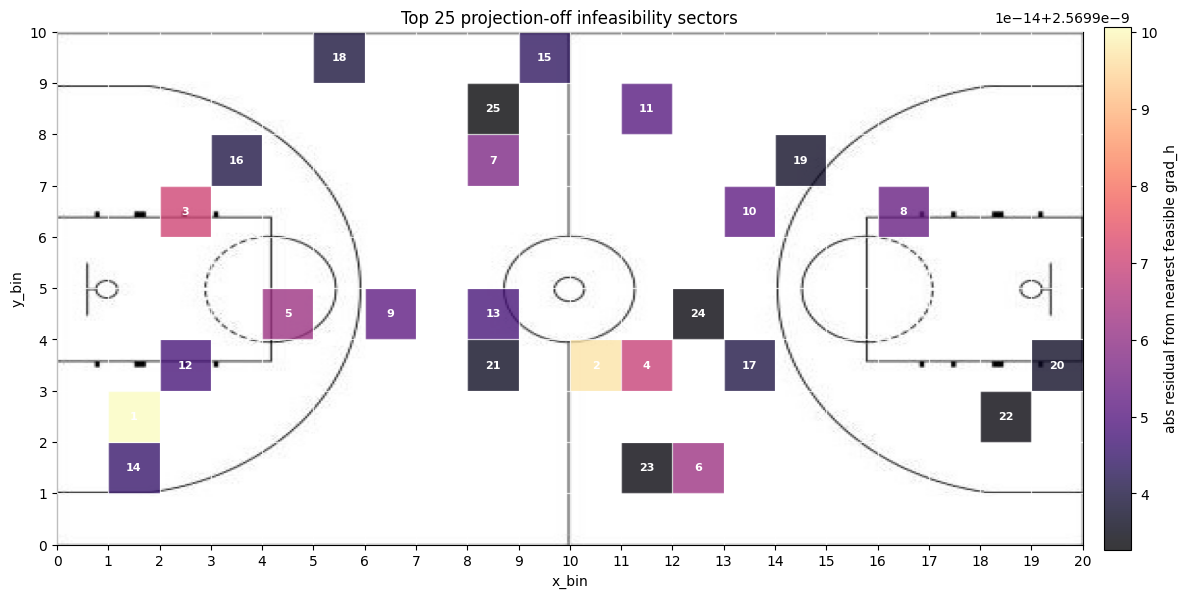

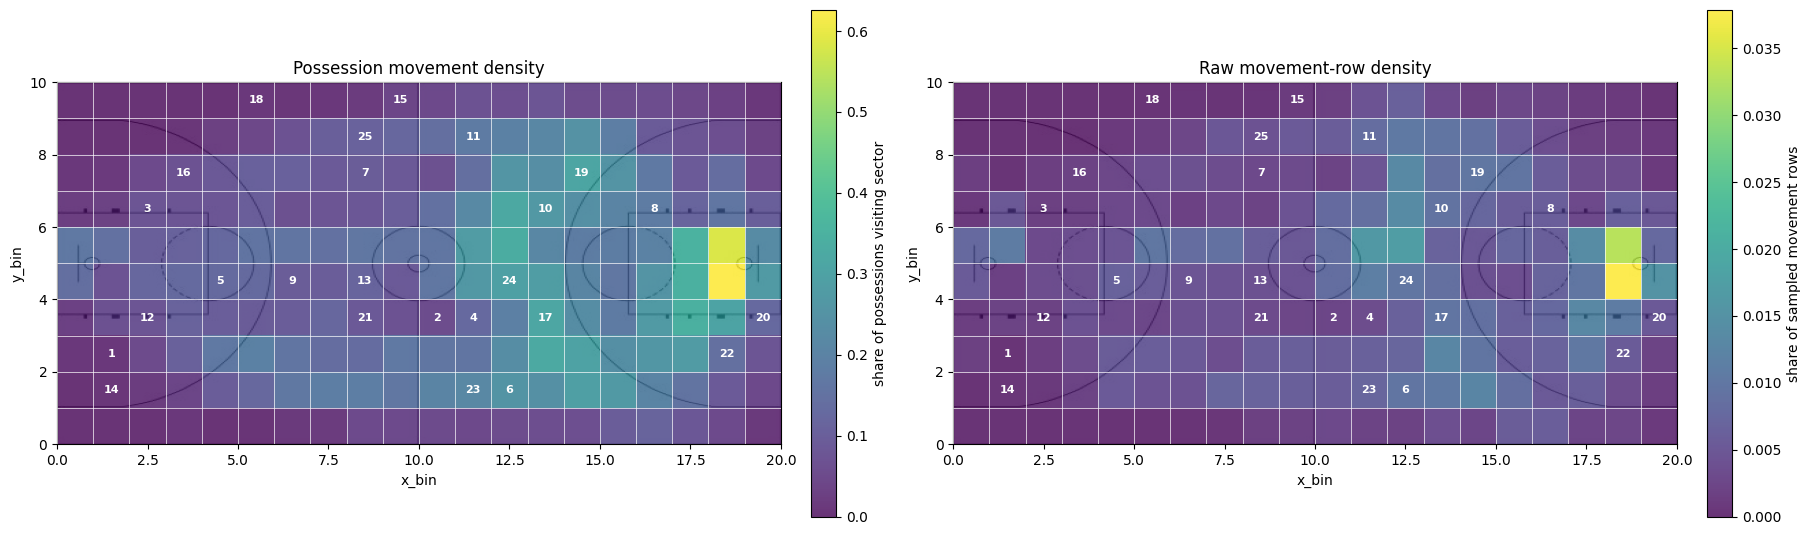

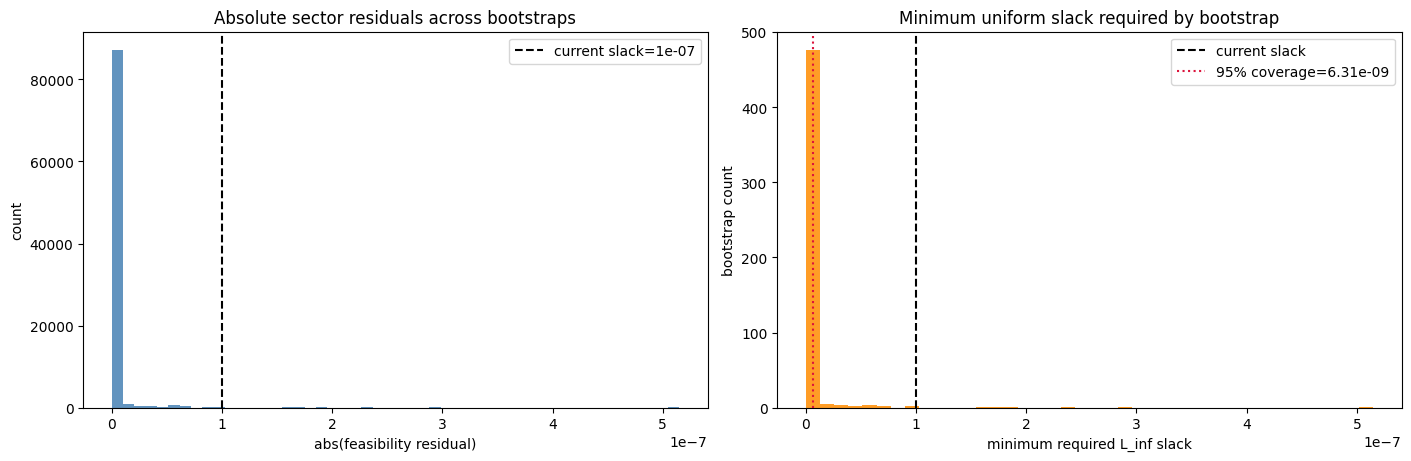

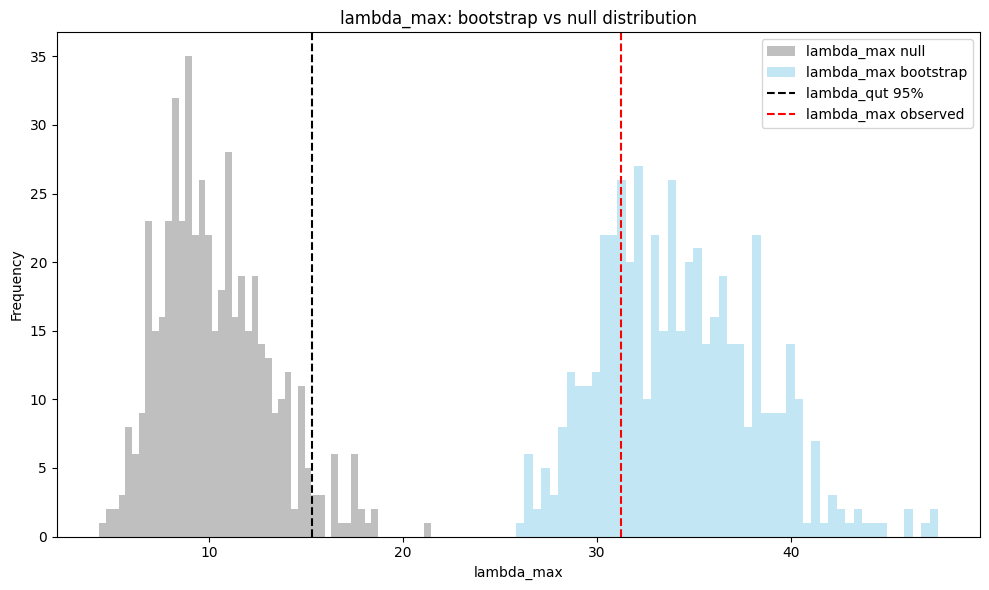

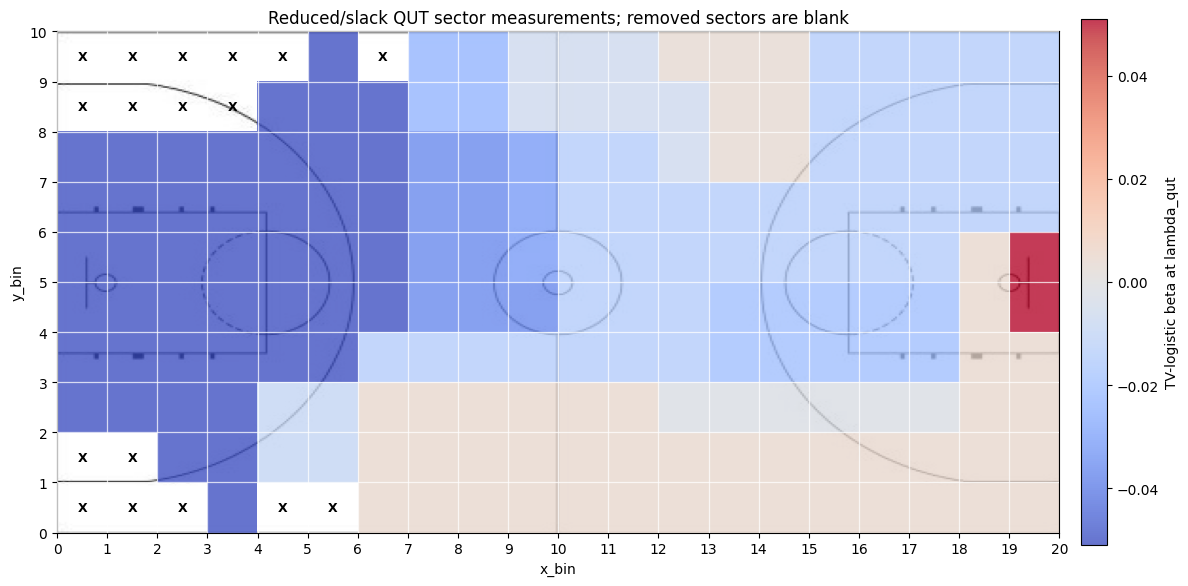

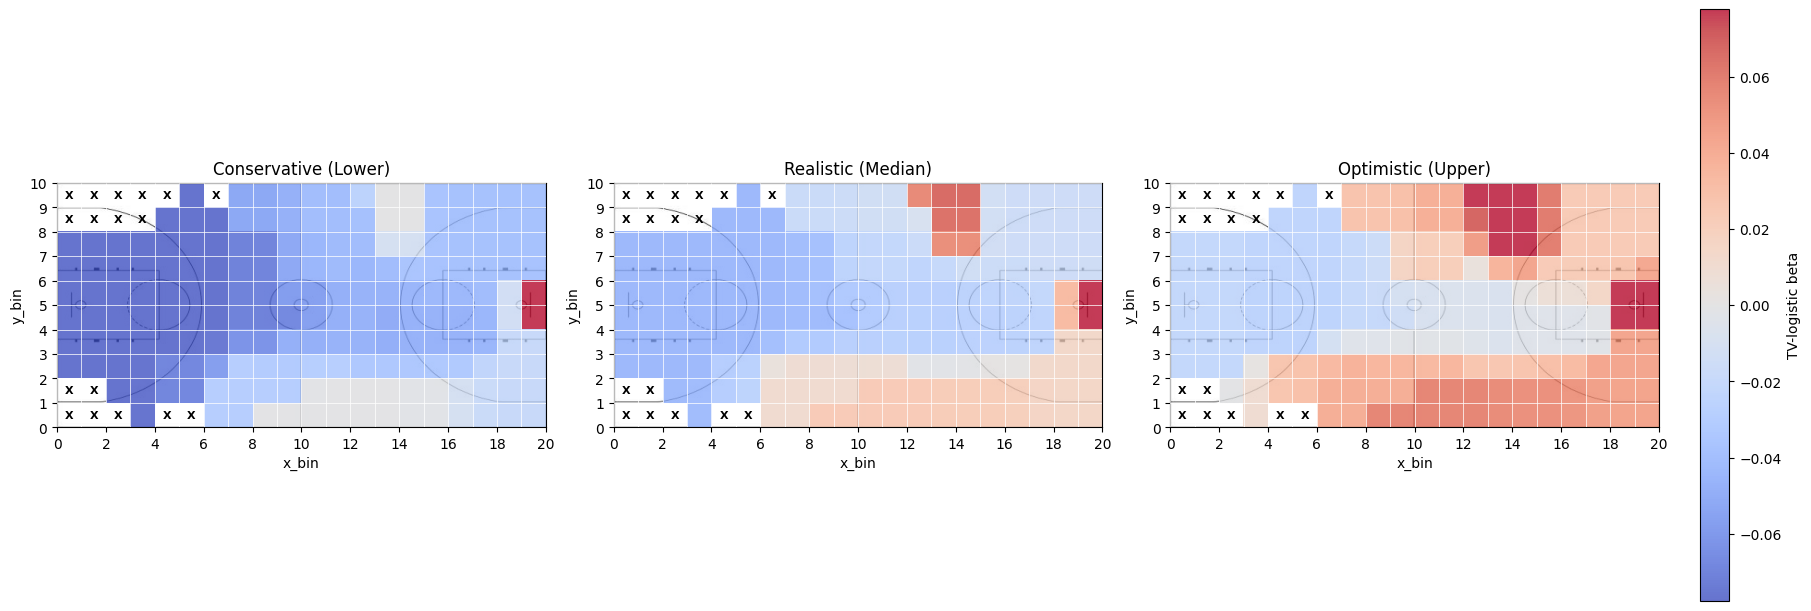

In [3]:
# Remove sectors represented by fewer than 10 possession-level observations from all downstream modelling and QUT mechanics.
MIN_SECTOR_OBSERVATIONS = 10

# Rebuild the same deterministic bootstrap-first analysis dataset so this cell
# reproduces the complete output sequence from the original analysis cell.
df_raw = pd.read_csv(DATA_PATH)
df = orient_qut_bins_left_to_right(df_raw)

required_cols = {"possession_number", "x_bin", "y_bin", "scored"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

orientation_method = df["qut_orientation_method"].iloc[0]
flipped_possessions = df.loc[df["qut_orientation_flipped"], "possession_number"].nunique()
total_possessions = df["possession_number"].nunique()
orientation_check = (
    df.sort_values(["possession_number", "time"], ascending=[True, False])
      .groupby("possession_number", sort=False)["x_bin"]
      .agg(start="first", end="last")
)
print(f"QUT bin orientation method: {orientation_method}")
print(f"Possessions flipped for left-to-right orientation: {flipped_possessions:,} / {total_possessions:,}")
print(f"Post-orientation mean end-start x_bin: {(orientation_check['end'] - orientation_check['start']).mean():.4f}")

print("Generating Bootstrapped Datasets...")
boot_datasets = funcs.generate_bootstrapped_datasets(
    df,
    n_bootstraps=N_BOOTSTRAPS,
    n_possessions_per_bootstrap=N_POSSESSIONS_PER_BOOTSTRAP,
    samples_per_possession=SAMPLES_PER_POSSESSION,
    min_samples_required=MIN_SAMPLES_REQUIRED,
    seed=BOOTSTRAP_SEED,
)
df_boot = boot_datasets[0]
X, y, D_TV = funcs.grid(df_boot)
variable_names = [f"x_bin={i // GRID_HEIGHT}, y_bin={i % GRID_HEIGHT}" for i in range(X.shape[1])]

# Repeat every diagnostic print, DataFrame, and plot produced by the original
# execution block before applying the additional observation-count rule.
print(f"Loaded {len(df):,} source rows from {DATA_PATH}")
print(f"Source possessions: {df['possession_number'].nunique():,}")
print(f"Bootstrap datasets: {len(boot_datasets):,}")
print(f"QUT bootstrap rows: {len(df_boot):,}")
print(f"QUT bootstrap possessions: {df_boot['possession_number'].nunique():,}")
print(f"X shape: {X.shape}; D_TV shape: {D_TV.shape}; scored rate: {y.mean():.4f}")
print("grad_h projection is OFF for this QUT run.")

diagnostics = diagnose_null_logistic_feasibility(
    y, X, D_TV,
    variable_names=variable_names,
    top_n=X.shape[1],
)
print("Null model: sklearn LogisticRegression(fit_intercept=False, penalty='l2', solver='lbfgs')")
print(f"null beta0: {diagnostics['null_fit']['beta0']:.12g}")
print(f"null penalty: {diagnostics['null_fit']['penalty']}")
print(f"null optimizer iterations: {diagnostics['null_fit']['n_iter']}")
print(f"null likelihood score: {diagnostics['null_fit']['likelihood_score']:.6g}")
print(f"sum(grad_h): {diagnostics['grad_h_sum']:.6g}")
print(f"non-representable constant offset: {diagnostics['constant_offset']:.6g}")
print(
    "Distance from grad_h to col(D_TV.T): "
    f"L2={diagnostics['residual_l2']:.6g}, "
    f"Linf={diagnostics['residual_linf']:.6g}"
)
print(
    f"rank(D_TV.T)={diagnostics['rank_D_transpose']} / "
    f"{diagnostics['n_variables']} variables"
)
display(diagnostics["top_variables"].head(INFEASIBLE_TOP_N))
fig, ax, infeasible_plot_variables = plot_infeasible_variables_on_court(
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N)
)
display(infeasible_plot_variables[["variable_index", "x_bin", "y_bin", "residual", "abs_residual"]])

sector_density_diagnostics = build_movement_density_diagnostics(
    df_boot, X, y, diagnostics
)
plot_movement_density_heatmaps(
    sector_density_diagnostics,
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N),
)
infeasible_neighbor_comparison = build_infeasible_neighbor_comparison(
    sector_density_diagnostics,
    diagnostics["top_variables"].head(INFEASIBLE_TOP_N),
)
infeasibility_hypothesis_summary = summarize_infeasibility_hypotheses(
    sector_density_diagnostics, diagnostics
)
display(infeasibility_hypothesis_summary.to_frame())
display(
    infeasible_neighbor_comparison.style.format({
        "possession_visit_rate": "{:.2%}",
        "scoring_rate_when_visited": "{:.3f}",
        "grad_h": "{:.6g}",
        "grad_h_difference_from_focal": "{:+.6g}",
        "residual": "{:.3g}",
        "abs_residual": "{:.3g}",
    })
)

# X is binary at the possession-sector level, so its column sums are the total
# number of model observations in which each sector was visited.
sector_observation_counts = np.asarray(X.sum(axis=0)).reshape(-1).astype(int)
low_observation_mask = sector_observation_counts < MIN_SECTOR_OBSERVATIONS

# Start from the notebook's existing feasibility/slack policy, then combine its
# removal mask with the minimum-observation rule.
feasibility_qut_system = build_reduced_qut_system(
    X,
    D_TV,
    diagnostics,
    remove_residual_tol=REMOVE_RESIDUAL_TOL,
    feasible_residual_tol=FEASIBLE_RESIDUAL_TOL,
)
feasibility_remove_mask = feasibility_qut_system["remove_mask"]
combined_remove_mask = feasibility_remove_mask | low_observation_mask
combined_keep_mask = ~combined_remove_mask

if not combined_keep_mask.any():
    raise ValueError("All sectors were removed by the feasibility and minimum-observation rules.")

# Remove every TV edge incident to an excluded sector so the QUT constraint and
# fitted TV penalty contain only retained coefficients.
D_TV_array = np.asarray(D_TV, dtype=float)
combined_edge_keep_mask = np.all(D_TV_array[:, combined_remove_mask] == 0, axis=1)
combined_keep_indices = np.flatnonzero(combined_keep_mask)

sector_status = feasibility_qut_system["sector_status"].copy()
sector_status["total_observations"] = sector_observation_counts
sector_status["below_minimum_observations"] = low_observation_mask
sector_status["removed_for_feasibility"] = feasibility_remove_mask
sector_status["qut_included"] = combined_keep_mask
sector_status["measurement_available"] = combined_keep_mask
sector_status["qut_action"] = np.select(
    [
        low_observation_mask & feasibility_remove_mask,
        low_observation_mask,
        feasibility_remove_mask,
        combined_keep_mask & (sector_status["abs_residual"].to_numpy() > FEASIBLE_RESIDUAL_TOL),
    ],
    [
        "remove_low_observations_and_infeasible",
        "remove_low_observations",
        "remove_infeasible_no_measurement",
        "keep_with_slack",
    ],
    default="keep_exact",
)

qut_system = {
    "X_reduced": X[:, combined_keep_mask],
    "D_reduced": D_TV_array[combined_edge_keep_mask][:, combined_keep_mask],
    "keep_mask": combined_keep_mask,
    "remove_mask": combined_remove_mask,
    "edge_keep_mask": combined_edge_keep_mask,
    "keep_indices": combined_keep_indices,
    "sector_status": sector_status,
}
removed_sectors = sector_status[~sector_status["measurement_available"]]
low_observation_sectors = sector_status[sector_status["below_minimum_observations"]]
slack_sectors = sector_status[sector_status["qut_action"] == "keep_with_slack"]

print(f"Sectors with fewer than {MIN_SECTOR_OBSERVATIONS} observations: {len(low_observation_sectors)}")
print(f"Removed sectors with no final measurement: {len(removed_sectors)}")
print(f"Kept sectors using bounded slack: {len(slack_sectors)}")
print(f"Kept sectors in QUT model: {qut_system['X_reduced'].shape[1]} / {X.shape[1]}")
print(f"Kept TV edges in QUT model: {qut_system['D_reduced'].shape[0]} / {D_TV.shape[0]}")
display(sector_status.sort_values("abs_residual", ascending=False).head(INFEASIBLE_TOP_N))

# Repeat the bootstrap feasibility diagnostic using the combined feasibility
# and minimum-observation mask from this specific QUT run.
minimum_observation_qut_residual_results = funcs.analyze_bootstrap_qut_feasibility(
    boot_datasets=boot_datasets,
    D_TV=qut_system["D_reduced"],
    keep_mask=qut_system["keep_mask"],
    variable_indices=qut_system["keep_indices"],
    current_slack_tol=SLACK_TOL,
    grid_height=GRID_HEIGHT,
)
latest_qut_residual_results = minimum_observation_qut_residual_results
print(
    f"Minimum-observation QUT slack coverage: "
    f"{minimum_observation_qut_residual_results['current_slack_bootstrap_coverage']:.1%}; "
    f"maximum required={minimum_observation_qut_residual_results['maximum_required_slack']:.6g} "
    f"({minimum_observation_qut_residual_results['maximum_slack_multiple']:.3g}x current slack)."
)
display(minimum_observation_qut_residual_results["distribution_summary"].style.format("{:.6g}"))
display(minimum_observation_qut_residual_results["slack_guidance"].style.format({
    "bootstrap_coverage_target": "{:.0%}",
    "suggested_slack_tol": "{:.6g}",
    "multiple_of_current_slack_tol": "{:.3g}",
}))
display(minimum_observation_qut_residual_results["per_bootstrap"].head(10))
display(minimum_observation_qut_residual_results["sector_summary"].head(INFEASIBLE_TOP_N))
funcs.plot_bootstrap_qut_feasibility(minimum_observation_qut_residual_results)
if not minimum_observation_qut_residual_results["failed_bootstraps"].empty:
    display(minimum_observation_qut_residual_results["failed_bootstraps"].head())

# Re-run QUT and every downstream model output with the combined sector mask.
lambda_qut_val, lambda_max_obs, lambdas_null, observed_slack, null_slack_linf, qut_solver = lambda_qut_with_slack(
    qut_system["X_reduced"],
    y,
    qut_system["D_reduced"],
    MC=MC_NULL,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
)
bootstrap_lambda_summary = compute_lambda_max_from_bootstraps_with_slack(
    boot_datasets[1:],
    qut_system,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
)
display(bootstrap_lambda_summary.head())

lambda_max_bootstrap = np.concatenate([
    np.asarray([lambda_max_obs], dtype=float),
    bootstrap_lambda_summary["lambda_max"].dropna().to_numpy(dtype=float),
])
qut_summary = summarize_lambda_max_bootstrap_analysis(
    lambda_max_obs=float(lambda_max_obs),
    lambda_max_null=np.asarray(lambdas_null, dtype=float),
    lambda_max_bootstrap=lambda_max_bootstrap,
    plot=PLOT_LAMBDA_DISTRIBUTIONS,
)

beta_reduced, beta_solver = fit_reduced_tv_logistic(
    qut_system["X_reduced"],
    y,
    qut_system["D_reduced"],
    lambda_tv=lambda_qut_val,
)
beta_grid = map_reduced_values_to_grid(beta_reduced, qut_system["keep_indices"])
sector_status["slack_used"] = np.nan
sector_status.loc[qut_system["keep_indices"], "slack_used"] = observed_slack
sector_status["beta_measurement"] = beta_grid.reshape(-1)
sector_status.loc[~sector_status["measurement_available"], "beta_measurement"] = np.nan
plot_qut_measurements_on_court(beta_grid, sector_status)

pointwise_results = None
if PLOT_POINTWISE_MAPS:
    print(f"Computing pointwise conservative/realistic/optimistic maps at lambda = {lambda_qut_val:.4f}")
    beta_med, beta_lo, beta_hi, pointwise_maps_all, pointwise_failures = bootstrap_reduced_percentile_maps_fixed_lambda(
        boot_datasets,
        qut_system,
        lambda_tv=lambda_qut_val,
        alpha=POINTWISE_ALPHA,
    )
    plot_pointwise_measurement_maps(beta_lo, beta_med, beta_hi, sector_status)
    if not pointwise_failures.empty:
        display(pointwise_failures.head())
    pointwise_results = {
        "alpha": POINTWISE_ALPHA,
        "beta_lo": beta_lo,
        "beta_med": beta_med,
        "beta_hi": beta_hi,
        "maps": pointwise_maps_all,
        "failures": pointwise_failures,
    }

qut_results.update({
    "minimum_sector_observations": MIN_SECTOR_OBSERVATIONS,
    "sector_observation_counts": sector_observation_counts,
    "low_observation_sectors": low_observation_sectors,
    "lambda_qut": lambda_qut_val,
    "lambda_max_obs": lambda_max_obs,
    "lambda_null": lambdas_null,
    "lambda_max_bootstrap": lambda_max_bootstrap,
    "bootstrap_lambda_summary": bootstrap_lambda_summary,
    "qut_summary": qut_summary,
    "observed_slack": observed_slack,
    "null_slack_linf": null_slack_linf,
    "qut_solver": qut_solver,
    "beta_solver": beta_solver,
    "sector_status": sector_status,
    "beta_grid": beta_grid,
    "pointwise": pointwise_results,
    "removed_sectors": removed_sectors,
    "qut_system": qut_system,
    "boot_datasets": boot_datasets,
    "df_boot": df_boot,
    "feasibility_diagnostics": diagnostics,
    "sector_density_diagnostics": sector_density_diagnostics,
    "infeasible_neighbor_comparison": infeasible_neighbor_comparison,
    "infeasibility_hypothesis_summary": infeasibility_hypothesis_summary,
    "minimum_observation_qut_residual_results": minimum_observation_qut_residual_results,
    "bootstrap_residual_results": minimum_observation_qut_residual_results,
    "bootstrap_residual_summary": minimum_observation_qut_residual_results["distribution_summary"],
    "bootstrap_slack_guidance": minimum_observation_qut_residual_results["slack_guidance"],
})
qut_results
